# Databricks notebook source

# Presentation du projet - Baseline contrefactuelle 15 min & comparaison XGBoost vs TFT

## Objectif general
Ce notebook construit une **baseline contrefactuelle** de consommation electrique a la
granularite **15 minutes** (aucune agregation horaire) pour **quatre segments** de clientele
d'Hydro-Quebec - **Pilote, Residentiel, Affaire et Comportemental** - puis compare deux familles
de modeles pour produire cette baseline : un **XGBoost** (Partie 1) et un **Temporal Fusion
Transformer / TFT** (Partie 2).

La baseline repond a la question : *"quelle aurait ete la consommation s'il n'y avait pas eu
d'evenement (effacement, appel de puissance) ?"*. En comparant cette consommation predite au
reel les jours d'evenement, on mesure l'**energie effacee**, la **precharge** et le **rebond**.

## Ce que fait le notebook, etape par etape
- **Chargement fusionne** des donnees de consommation des 4 segments + meteo ponderee (Spark SQL).
- **Nettoyage 15 min** : mise sur grille reguliere, gestion des trous, exclusion des labels non finis.
- **Ingenierie de variables** : calendrier, cyclicite (sin/cos), meteo retardee (lag 24 h et delta),
  interactions temperature, profils de reference par creneau, one-hot du jour de semaine.
- **Detection automatique de maintenance / rebond** pour ne pas polluer l'apprentissage de la baseline.
- **Modelisation residuelle** : la cible est `energie - profil_ref_final`, avec **contraintes de
  monotonie** (HDD/CDD), objectif robuste (pseudo-Huber), **debiaisage local** et **clipping**.
- **Backtest a date fixe** (`DATE_TEST`) sur une fenetre encadrant l'evenement.
- **Syntheses** : metriques par segment, resume journalier avec statut, bilan de deplacement de charge.
- **Partie 2 (TFT)** : entrainement sur l'historique anterieur au test, puis **baseline glissante
  jour par jour** (encoder = 7 jours reels, decoder = 96 creneaux calendrier + meteo, sans fuite),
  et **comparaison XGBoost vs TFT** sur les jours propres.

## Points cles de conception
- **Anti-fuite** : le decodeur du TFT ne voit que le calendrier et la meteo, jamais l'evenement.
- **Robustesse** : gestion explicite des NaN de grille 15 min (correctif `Label contains NaN`).
- **Persistance** : les modeles TFT sont sauvegardes dans un Volume Unity Catalog pour reutilisation.
- **Reproductibilite** : graines fixees (`SEED`, `SEED_TFT`), device GPU/CPU detecte automatiquement.

## Comment lire ce notebook
Chaque cellule de code est desormais precedee d'une **explication detaillee** decrivant son role,
ses entrees/sorties et les points d'attention. Le **code d'origine n'a pas ete modifie** : seules
des cellules Markdown explicatives ont ete ajoutees.

# Backtest Affaire ameliore - GRANULARITE 15 MINUTES

Version **15 minutes** (aucune agregation horaire) integrant les ameliorations Affaire.

**Correctif de cette version** : l'erreur `XGBoostError: Label contains NaN` est resolue.
Elle venait de deux sources introduites par le passage en 15 min :
1. le **reindex sur grille 15 min** cree des lignes ou `energie` est NaN (trous combles) ;
2. `profil_ref_final` pouvait etre **NaN** pour des creneaux absents du train baseline.
Comme la cible residuelle est `energie - profil_ref_final`, un seul NaN faisait echouer `fit`.
On garantit desormais un **profil sans NaN** (fallback global) et on **exclut du fit** toute
ligne dont le label ou l'energie n'est pas finie.

> Conversions 15 min validees hors Spark ; correctif label teste (fit sans erreur).

## 1. Imports

### Explication detaillee - Cellule 1 : Imports et configuration
Cette cellule prepare l'environnement d'execution.
- **`_assurer(pkg, pip_name)`** : petite fonction utilitaire qui tente d'importer un paquet et, s'il
  est absent, l'installe silencieusement via `pip` avant de le reimporter. Cela rend le notebook
  autonome sur un cluster ou XGBoost/scikit-learn ne seraient pas preinstalles.
- **Imports scientifiques** : `numpy`, `pandas`, `matplotlib` pour le calcul et les graphiques ;
  `XGBRegressor`, `Pipeline`, `SimpleImputer` et les metriques (`RMSE`, `MAE`, `R2`) de scikit-learn.
- **Options d'affichage** : on augmente le nombre de colonnes/largeur affichees par pandas et on fixe
  la taille par defaut des figures matplotlib avec une grille active.
- **Sortie** : impression des versions de XGBoost et scikit-learn pour tracabilite, puis `Imports OK`.

In [0]:
import os, sys, subprocess, warnings, importlib
warnings.filterwarnings("ignore")

def _assurer(pkg, pip_name=None):
    try:
        return importlib.import_module(pkg)
    except ModuleNotFoundError:
        print(f"Installation de {pip_name or pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return importlib.import_module(pkg)

xgb = _assurer("xgboost")
_assurer("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sklearn

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)
plt.rcParams["figure.figsize"] = (16, 6)
plt.rcParams["axes.grid"] = True
print("XGBoost:", xgb.__version__, "| scikit-learn:", sklearn.__version__)
print("Imports OK")

XGBoost: 2.0.3 | scikit-learn: 1.4.2
Imports OK


## 2. Parametres - granularite 15 min, fenetre test et ameliorations

### Explication detaillee - Cellule 2 : Parametres globaux
Toute la configuration du backtest est centralisee ici (aucun calcul lourd).
- **Granularite** : `FREQ = "15min"`, avec `PAS_PAR_HEURE = 4` et `PAS_PAR_JOUR = 96` creneaux.
- **Fenetre de test** : `DATE_TEST` est la date cible ; on prend `NB_JOURS_AVANT`/`NB_JOURS_APRES`
  jours de part et d'autre pour encadrer l'evenement. `debut_test`/`fin_test` en decoulent.
- **Phases d'evenement** : `PRE_PAS`/`POST_PAS` definissent les creneaux avant/apres l'evenement,
  et `JOURS_AVANT_EVENT`/`JOURS_APRES_EVENT` marquent les jours voisins (J-1, J+1).
- **Exclusions baseline** : on retire du train les jours d'evenement, la veille, le lendemain et
  les journees de maintenance pour que la baseline apprenne un comportement "normal".
- **Ameliorations activables** (flags booleens) : cible residuelle, one-hot du jour de semaine,
  interactions temperature, contraintes de monotonie, objectif robuste `reg:pseudohubererror`,
  debiaisage local, clipping des predictions, detection de maintenance.
- **Trous de grille** : options d'interpolation des petits trous d'energie (desactive par defaut).
- **Sortie** : recapitulatif imprime de la granularite, de la fenetre et des options actives.

In [0]:
# ============================================================
# GRANULARITE  ->  15 MINUTES (aucune agregation horaire)
# ============================================================
FREQ           = "15min"
PAS_PAR_HEURE  = 4
PAS_PAR_JOUR   = 24 * PAS_PAR_HEURE   # 96

# ============================================================
# BACKTEST DATE FIXE
# ============================================================
DATE_TEST = "2026-03-03"
NB_JOURS_AVANT = 8
NB_JOURS_APRES = 8
SEED = 42
np.random.seed(SEED)

PRE_PAS          = 2 * PAS_PAR_HEURE   # 8 pas
POST_PAS         = 2 * PAS_PAR_HEURE   # 8 pas
JOURS_AVANT_EVENT = 1
JOURS_APRES_EVENT = 1

EXCLURE_JOUR_AVANT_BASELINE = True
EXCLURE_JOUR_EVENT_BASELINE = True
EXCLURE_JOUR_APRES_BASELINE = True

UTILISER_ROLLS_DANS_BASELINE = False
UTILISER_LAGS_DANS_BASELINE  = False

AJOUTER_CYCLICITE_HEBDO = True
AJOUTER_PROFILS_HEBDO   = True
AJOUTER_METEO_LAG_24H   = True
AJOUTER_METEO_DELTA_24H = True

# Ameliorations
MODE_CIBLE_RESIDU = True
AJOUTER_DOW_ONEHOT       = True
AJOUTER_INTERACTIONS_TEMP = True
UTILISER_MONOTONE = True
OBJECTIF_XGB = "reg:pseudohubererror"
DEBIASAGE_LOCAL = True
JOURS_CALIB_DEBIAIS = 30
CLIP_PREDICTIONS = True
CLIP_Q_BAS, CLIP_Q_HAUT = 0.001, 0.999
DETECTER_MAINTENANCE      = True
EXCLURE_MAINTENANCE_TRAIN = True
MAINT_RATIO_SEUIL = 0.75
MAINT_CV_SEUIL    = 0.12
MAINT_N_VOISINS   = 4
REBOND_RATIO_SEUIL = 1.10

# Gestion des trous de grille 15 min
INTERPOLER_ENERGIE_TROUS = False   # True = interpole lineairement les petits trous d'energie
MAX_TROU_INTERP = 4                # nb max de pas consecutifs interpolables (=1 h)

SEUIL_FROID_CONSEC = 15.0

DATE_TEST_TS = pd.Timestamp(DATE_TEST).normalize()
debut_test = DATE_TEST_TS - pd.Timedelta(days=NB_JOURS_AVANT)
fin_test   = DATE_TEST_TS + pd.Timedelta(days=NB_JOURS_APRES + 1) - pd.Timedelta(minutes=15)

print(f"Granularite : {FREQ} ({PAS_PAR_JOUR} pas/jour)")
print("Date test :", DATE_TEST_TS.date(), "| Fenetre :", debut_test, "->", fin_test)
print("Cible residu :", MODE_CIBLE_RESIDU, "| Monotone :", UTILISER_MONOTONE,
      "| Debias local :", DEBIASAGE_LOCAL, "| Detect maintenance :", DETECTER_MAINTENANCE)

Granularite : 15min (96 pas/jour)
Date test : 2026-03-03 | Fenetre : 2026-02-23 00:00:00 -> 2026-03-11 23:45:00
Cible residu : True | Monotone : True | Debias local : True | Detect maintenance : True


## 3. Detection GPU / CPU

### Explication detaillee - Cellule 3 : Detection GPU / CPU
- **`detecter_device()`** verifie d'abord que XGBoost est en version >= 2.0 (sinon CPU force, car
  l'API `device` n'existe pas avant). Elle interroge ensuite `nvidia-smi` pour detecter un GPU.
- Si un GPU est present, elle renvoie `"cuda"` (entrainement accelere) ; sinon `"cpu"`.
- **`DEVICE`** stocke ce choix et sera passe a chaque `XGBRegressor` plus loin, garantissant que
  le meme notebook fonctionne indifferemment sur un cluster CPU ou GPU.

In [0]:
def detecter_device():
    if int(xgb.__version__.split('.')[0]) < 2:
        print("XGBoost < 2.0 -> CPU force"); return "cpu"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
            stderr=subprocess.DEVNULL).decode().strip()
        if out:
            print(f"GPU detecte : {out} -> device='cuda'"); return "cuda"
    except Exception:
        pass
    print("Aucun GPU detecte -> device='cpu'"); return "cpu"

DEVICE = detecter_device()

GPU detecte : NVIDIA H100 NVL, 95830 MiB -> device='cuda'


## 4. Chargement fusionne : Pilote + Residentiel + Affaire + meteo

### Explication detaillee - Cellule 4 : Chargement fusionne (Spark SQL)
Cette cellule construit et execute une requete Spark SQL qui rassemble tout en une table.
- **`meteo_historique_poid`** : ajoute un poids aux stations meteo (la station `CYQC` pese 1, les
  autres 3) pour calculer ensuite une **meteo ponderee** (rayonnement, nebulosite, humidex, vent).
- **`donnees_meteo`** : agrege la meteo a l'heure via une moyenne ponderee par les poids ci-dessus.
- **`dateEvenementAffaire` / `dateEvenementResidentiel`** : listes de dates d'evenement propres a
  chaque segment, servant a marquer les indicateurs `Evenement_Aff` et `Evenement_Res`.
- **SELECT principal** : joint les colonnes d'energie/HDD/CDD des 4 segments (Pilote, Residentiel,
  Affaire, Comportemental), les indicateurs d'evenement, le jour ferie et la meteo horaire.
- **Cote Python** : `spark.sql(...).toPandas()` ramene le tout dans un DataFrame pandas trie par
  `Intervalle`, puis on verifie le **pas temporel median** (attendu 15 min) et on affiche un apercu.

In [0]:
query_fusion = """
WITH meteo_historique_poid AS (
    SELECT *, CASE WHEN ville = 'CYQC' THEN 1 ELSE 3 END AS poids
    FROM ct_prd_conf.db_xkj_zx_expdonnees_intmarche_conception.meteo_historique
),
donnees_meteo AS (
    SELECT
        TO_TIMESTAMP(CONCAT(CAST(date AS STRING), ' ', heure2)) AS Intervalle,
        SUM(rayHomo  * poids) / SUM(poids) AS rayHomo,
        SUM(nebu     * poids) / SUM(poids) AS nebu,
        SUM(humidex  * poids) / SUM(poids) AS humidex,
        SUM(VentHomo * poids) / SUM(poids) AS VentHomo
    FROM meteo_historique_poid
    GROUP BY TO_TIMESTAMP(CONCAT(CAST(date AS STRING), ' ', heure2))
),
dateEvenementAffaire AS (
    SELECT DISTINCT CAST(Date_Debut AS date) AS IntervalleDate
    FROM ct_prd_conf.db_xkj_zx_expdonnees_intmarche_ingestion.appels_mdg_mw
),
dateEvenementResidentiel AS (
    SELECT DISTINCT DateEvenement
    FROM ct_prd_conf.db_xkj_zx_expdonnees_intmarche_conception.donnees_evenement_details_historique20_26_V3
)
SELECT
    a.Intervalle,
    a.Energie_pilote, a.HDD15_pilote, a.CDD18_pilote, a.tx_pilote,
    a.joursEven_pilot, a.Evenement_pilot,
    a.Energie_res, a.HDD15_res, a.CDD18_res,
    a.Energie_non_res, a.HDD15_non_res, a.CDD18_non_res,
    -- ==== AJOUT : segment Comportemental (clients NON pilotes) ====
    -- NB : adapter les noms si differents dans multi_profil_ajoutColonnes
    a.Energie_comp, a.HDD15_comp, a.CDD18_comp,
    a.tx_comp, a.joursEven_comp, a.Evenement_comportemental,
    a.JourFerieHQ,
    CASE WHEN b.IntervalleDate IS NOT NULL THEN 1 ELSE 0 END AS Evenement_Aff,
    CASE WHEN c.DateEvenement  IS NOT NULL THEN 1 ELSE 0 END AS Evenement_Res,
    d.rayHomo, d.nebu, d.humidex, d.VentHomo
FROM ct_prd_conf.db_xkj_zx_expdonnees_intmarche_conception.multi_profil_ajoutColonnes a
LEFT JOIN donnees_meteo d
    ON DATE_TRUNC('hour', a.Intervalle) = d.Intervalle
LEFT JOIN dateEvenementAffaire b
    ON CAST(a.Intervalle AS date) = b.IntervalleDate
LEFT JOIN dateEvenementResidentiel c
    ON CAST(a.Intervalle AS date) = c.DateEvenement
"""

pdf = spark.sql(query_fusion).toPandas()
pdf["Intervalle"] = pd.to_datetime(pdf["Intervalle"])
pdf = pdf.sort_values("Intervalle").reset_index(drop=True)
print("Donnees fusionnees :", pdf.shape, "| Plage :", pdf["Intervalle"].min(), "->", pdf["Intervalle"].max())
ecart = pdf["Intervalle"].diff().dropna().median()
print("Pas temporel median detecte :", ecart, "(attendu 0 days 00:15:00)")
display(pdf.head())

Donnees fusionnees : (230852, 26) | Plage : 2020-01-01 00:00:00 -> 2026-08-01 23:45:00
Pas temporel median detecte : 0 days 00:15:00 (attendu 0 days 00:15:00)


Intervalle,Energie_pilote,HDD15_pilote,CDD18_pilote,tx_pilote,joursEven_pilot,Evenement_pilot,Energie_res,HDD15_res,CDD18_res,Energie_non_res,HDD15_non_res,CDD18_non_res,Energie_comp,HDD15_comp,CDD18_comp,tx_comp,joursEven_comp,Evenement_comportemental,JourFerieHQ,Evenement_Aff,Evenement_Res,rayHomo,nebu,humidex,VentHomo
2020-01-01T00:00:00Z,0.7300683240018353,null,null,0.0,0,0,0.6122323986801416,null,null,5.393508490074274,null,null,0.6570547847230275,null,null,0.0,0,0,1,0,0,0.0,5.714285714285714,-0.5,15.428571428571429
2020-01-01T00:15:00Z,0.7268353485468793,null,null,0.0,0,0,0.6094689680319116,null,null,5.424546010578861,null,null,0.6546532565724669,null,null,0.0,0,0,1,0,0,0.0,5.714285714285714,-0.5,15.428571428571429
2020-01-01T00:30:00Z,0.7297681176978071,null,null,0.0,0,0,0.608247234482942,null,null,5.323097055618282,null,null,0.6532912145720633,null,null,0.0,0,0,1,0,0,0.0,5.714285714285714,-0.5,15.428571428571429
2020-01-01T00:45:00Z,0.729194963243054,null,null,0.0,0,0,0.6080673752645385,null,null,5.367041374930914,null,null,0.6536040868261838,null,null,0.0,0,0,1,0,0,0.0,5.714285714285714,-0.5,15.428571428571429
2020-01-01T01:00:00Z,0.7320406771105786,null,null,0.0,0,0,0.6064667261486518,null,null,5.349201983721107,null,null,0.6531453088143263,null,null,0.0,0,0,1,0,0,0.0,5.714285714285714,-0.5142857142857143,9.857142857142858


## 5. Configuration des 4 segments (Pilote, Residentiel, Affaire, Comportemental)

### Explication detaillee - Cellule 5 : Configuration des 4 segments
- **`SEGMENTS`** est un dictionnaire qui associe a chaque segment le nom des colonnes a utiliser :
  energie, HDD, CDD, indicateur d'evenement, taux (`tx`) et jours d'evenement quand ils existent.
- Il stocke aussi les **couleurs** de trace (reel, prediction, bandes d'evenement) propres a chaque
  segment, ce qui uniformise l'apparence des graphiques produits plus loin.
- Ce mapping permet a tout le pipeline aval de rester **generique** : les fonctions lisent la config
  d'un segment plutot que des noms de colonnes codes en dur, d'ou une boucle unique sur les 4 segments.

In [0]:
SEGMENTS = {
    "Pilote": {
        "energie": "Energie_pilote", "hdd": "HDD15_pilote", "cdd": "CDD18_pilote",
        "event": "Evenement_pilot",  "tx": "tx_pilote",     "jours_even": "joursEven_pilot",
        "couleur_reel": "black", "couleur_pred": "crimson", "couleur_event": "crimson"},
    "Residentiel": {
        "energie": "Energie_res", "hdd": "HDD15_res", "cdd": "CDD18_res",
        "event": "Evenement_Res", "tx": None, "jours_even": None,
        "couleur_reel": "black", "couleur_pred": "royalblue", "couleur_event": "royalblue"},
    "Affaire": {
        "energie": "Energie_non_res", "hdd": "HDD15_non_res", "cdd": "CDD18_non_res",
        "event": "Evenement_Aff", "tx": None, "jours_even": None,
        "couleur_reel": "navy", "couleur_pred": "darkorange", "couleur_event": "darkorange"},
    # ==== AJOUT : Comportemental = clients NON pilotes (colonnes d'evenement dediees) ====
    "Comportemental": {
        "energie": "Energie_comp", "hdd": "HDD15_comp", "cdd": "CDD18_comp",
        "event": "Evenement_comportemental", "tx": "tx_comp", "jours_even": "joursEven_comp",
        "couleur_reel": "black", "couleur_pred": "seagreen", "couleur_event": "seagreen"},
}

## 6. Alignement 15 min par segment (SANS agregation horaire)

On aligne sur une grille reguliere de 15 min. Le reindex comble les trous : les lignes
manquantes ont `energie=NaN`. **Ces lignes seront exclues du fit** (voir cellule 13) ou
interpolees si `INTERPOLER_ENERGIE_TROUS=True`.

### Explication detaillee - Cellule 6 : Alignement 15 min par segment
- **`preparer_segment(pdf_src, cfg)`** extrait, pour un segment donne, les colonnes utiles et les
  **renomme** vers des noms standard (`energie`, `hdd`, `cdd`, `event`) grace a la config du segment.
- Elle conserve aussi les colonnes communes (meteo, jour ferie) et, si disponibles, `tx`/`jours_even`.
- L'objectif est de mettre chaque segment au **meme format tabulaire**, aligne sur la grille 15 min,
  afin que les etapes suivantes (features, masks, modele) s'appliquent de facon identique a tous.

In [0]:
def preparer_segment(pdf_src, cfg):
    ren = {cfg["energie"]: "energie", cfg["hdd"]: "hdd", cfg["cdd"]: "cdd", cfg["event"]: "event"}
    cols = list(ren.keys()) + ["Intervalle", "JourFerieHQ", "rayHomo", "nebu", "humidex", "VentHomo"]
    if cfg["tx"]:         cols.append(cfg["tx"])
    if cfg["jours_even"]: cols.append(cfg["jours_even"])
    cols = [c for c in cols if c in pdf_src.columns]
    d = pdf_src[cols].copy().rename(columns=ren)

    d["tx"] = pdf_src[cfg["tx"]].values if (cfg["tx"] and cfg["tx"] in pdf_src.columns) \
              else d["event"].fillna(0).astype(float)
    d["jours_even"] = pdf_src[cfg["jours_even"]].values if (cfg["jours_even"] and cfg["jours_even"] in pdf_src.columns) \
                      else d["event"].fillna(0).astype(float)

    d["Intervalle"] = pd.to_datetime(d["Intervalle"]).dt.floor(FREQ)
    agg = {"energie": "sum", "hdd": "mean", "cdd": "mean", "event": "max", "tx": "max",
           "jours_even": "max", "JourFerieHQ": "max", "rayHomo": "mean", "nebu": "mean",
           "humidex": "mean", "VentHomo": "mean"}
    agg = {k: v for k, v in agg.items() if k in d.columns}
    d = d.groupby("Intervalle", as_index=False).agg(agg).sort_values("Intervalle").reset_index(drop=True)

    # Grille complete 15 min
    grille = pd.date_range(d["Intervalle"].min(), d["Intervalle"].max(), freq=FREQ)
    n_avant = len(d)
    d = d.set_index("Intervalle").reindex(grille).rename_axis("Intervalle").reset_index()
    n_trous = int(d["energie"].isna().sum())

    # Interpolation optionnelle des petits trous d'energie
    if INTERPOLER_ENERGIE_TROUS and n_trous:
        d["energie"] = d["energie"].interpolate(method="linear", limit=MAX_TROU_INTERP, limit_area="inside")
        n_trous = int(d["energie"].isna().sum())

    d["event"] = d["event"].fillna(0).astype(int)
    d["JourFerieHQ"] = d.get("JourFerieHQ", 0)
    d["JourFerieHQ"] = d["JourFerieHQ"].fillna(0).astype(int)

    pas_median = d["Intervalle"].diff().dropna().median()
    n_par_jour = d.groupby(d["Intervalle"].dt.normalize()).size()
    print(f"  [{cfg['energie']}] pas median={pas_median} | points/jour median={int(n_par_jour.median())} "
          f"(attendu {PAS_PAR_JOUR}) | trous energie restants={n_trous}")
    return d

## 7. Variables evenementielles (phases en PAS de 15 min)

### Explication detaillee - Cellule 7 : Variables evenementielles
- **`ajouter_variables_evenement(...)`** construit les indicateurs lies aux evenements a partir de la
  colonne brute `event` et du taux `tx`.
- Elle derive des champs temporels intra-jour (`heure`, `minute`, `date`) et marque les **phases** :
  creneaux d'evenement, creneaux avant (`PRE_PAS`) et apres (`POST_PAS`), ainsi que les **jours**
  J-1 et J+1 autour de chaque evenement.
- Ces variables serviront a la fois a l'exclusion du train baseline et a l'analyse du deplacement
  de charge (precharge/rebond) dans les cellules de bilan.

In [0]:
def ajouter_variables_evenement(df, pre_pas=PRE_PAS, post_pas=POST_PAS,
                                jours_avant=JOURS_AVANT_EVENT, jours_apres=JOURS_APRES_EVENT):
    d = df.copy().sort_values("Intervalle").reset_index(drop=True)
    d["tx"]    = d["tx"].fillna(0).astype(float).clip(0, 1)
    d["event"] = d["event"].fillna(0).astype(int)
    d["date"]  = d["Intervalle"].dt.normalize()
    d["heure"] = d["Intervalle"].dt.hour
    d["minute"] = d["Intervalle"].dt.minute

    d["is_event_day"] = d.groupby("date")["event"].transform("max").astype(int)
    chg = d["event"].ne(d["event"].shift()).cumsum()
    d["bloc_event"] = np.where(d["event"] == 1, chg, 0)

    d["phase_prechauffe"] = 0; d["phase_event"] = d["event"]; d["phase_reprise"] = 0
    idx_event = np.where(d["event"].values == 1)[0]; n = len(d)
    for i in idx_event:
        for k in range(1, pre_pas + 1):
            if i - k >= 0 and d["event"].iat[i - k] == 0:
                d.iat[i - k, d.columns.get_loc("phase_prechauffe")] = 1
        for k in range(1, post_pas + 1):
            if i + k < n and d["event"].iat[i + k] == 0:
                d.iat[i + k, d.columns.get_loc("phase_reprise")] = 1

    nb_blocs = d.loc[d["event"] == 1].groupby("date")["bloc_event"].nunique()
    d["nb_evenements_jour"] = d["date"].map(nb_blocs).fillna(0).astype(int)
    d["double_event"] = (d["nb_evenements_jour"] >= 2).astype(int)
    d["event_am"]   = ((d["event"] == 1) & (d["heure"] < 12)).astype(int)
    d["event_pm"]   = ((d["event"] == 1) & (d["heure"].between(12, 17))).astype(int)
    d["event_soir"] = ((d["event"] == 1) & (d["heure"] >= 18)).astype(int)

    jours_avec_event = set(d.loc[d["is_event_day"] == 1, "date"].unique())
    d["jour_avant_event"] = 0; d["jour_apres_event"] = 0
    for j in jours_avec_event:
        for k in range(1, jours_avant + 1):
            d.loc[d["date"] == (j - pd.Timedelta(days=k)), "jour_avant_event"] = 1
        for k in range(1, jours_apres + 1):
            d.loc[d["date"] == (j + pd.Timedelta(days=k)), "jour_apres_event"] = 1
    d.loc[d["is_event_day"] == 1, ["jour_avant_event", "jour_apres_event"]] = 0
    d["zone_event_etendue"] = ((d["is_event_day"] == 1) | (d["jour_avant_event"] == 1) |
                               (d["jour_apres_event"] == 1)).astype(int)
    return d

## 8. Detection maintenance / rebond - reference locale meme-jour-de-semaine

### Explication detaillee - Cellule 8 : Detection maintenance / rebond
Deux fonctions collaborent pour reperer les journees atypiques.
- **`classifier_journees_maintenance(...)`** agrege l'energie par jour, calcule pour chaque jour une
  **reference locale** (mediane des memes jours de semaine voisins) et un ratio energie/reference.
  Une journee est marquee **maintenance** si sa consommation est anormalement basse ET peu variable
  (faible coefficient de variation) hors evenement ; elle est marquee **rebond/precharge** si elle
  est anormalement haute hors evenement.
- **`joindre_flags_maintenance(d)`** fusionne ces indicateurs (`flag_maintenance`,
  `flag_rebond_precharge`) au DataFrame 15 min et imprime le decompte des journees concernees.
- But : eviter que des baisses techniques (maintenance) faussent l'apprentissage de la baseline.

In [0]:
def classifier_journees_maintenance(d, ratio_maint=MAINT_RATIO_SEUIL, cv_maint=MAINT_CV_SEUIL,
                                    n_vois=MAINT_N_VOISINS, ratio_reb=REBOND_RATIO_SEUIL):
    jour = d.groupby("date").agg(
        energie_jour=("energie", "sum"), moy_h=("energie", "mean"),
        std_h=("energie", "std"), n_event=("event", "sum")).reset_index()
    jour["jour_semaine"] = jour["date"].dt.dayofweek
    jour["cv_intra"] = jour["std_h"] / jour["moy_h"].replace(0, np.nan)
    jour = jour.sort_values("date").reset_index(drop=True)
    ref_local = np.full(len(jour), np.nan)
    for dow in range(7):
        sub = jour.index[jour["jour_semaine"] == dow].tolist()
        vals = jour.loc[sub, "energie_jour"].values
        for k, gi in enumerate(sub):
            lo = max(0, k - n_vois); hi = min(len(sub), k + n_vois + 1)
            voisins = np.concatenate([vals[lo:k], vals[k+1:hi]])
            if len(voisins): ref_local[gi] = np.median(voisins)
    jour["ref_local"] = ref_local
    jour["ratio_local"] = jour["energie_jour"] / jour["ref_local"]
    cv_ref = jour.loc[jour["n_event"] == 0, "cv_intra"].median()
    jour["flag_maintenance"] = (
        (jour["ratio_local"] <= ratio_maint) &
        (jour["cv_intra"] <= max(cv_maint, 0.6 * (cv_ref if pd.notna(cv_ref) else cv_maint))) &
        (jour["n_event"] == 0)).astype(int)
    jour["flag_rebond_precharge"] = (
        (jour["ratio_local"] >= ratio_reb) & (jour["n_event"] == 0) &
        (jour["flag_maintenance"] == 0)).astype(int)
    return jour[["date", "energie_jour", "ref_local", "ratio_local", "cv_intra",
                 "flag_maintenance", "flag_rebond_precharge"]]


def joindre_flags_maintenance(d):
    if not DETECTER_MAINTENANCE:
        d["flag_maintenance"] = 0; d["flag_rebond_precharge"] = 0; return d, None
    jour = classifier_journees_maintenance(d)
    d = d.merge(jour[["date", "flag_maintenance", "flag_rebond_precharge", "ratio_local", "cv_intra"]],
                on="date", how="left")
    d["flag_maintenance"] = d["flag_maintenance"].fillna(0).astype(int)
    d["flag_rebond_precharge"] = d["flag_rebond_precharge"].fillna(0).astype(int)
    print(f"  Journees maintenance : {int(jour['flag_maintenance'].sum())} | rebond/precharge : {int(jour['flag_rebond_precharge'].sum())}")
    return d, jour

## 9. Features communes 15 min - creneau intra-jour, cyclicite fine, meteo retardee

### Explication detaillee - Cellule 9 : Features communes 15 min
- **`_ajouter_meteo_lag_delta(d)`** cree, pour chaque variable meteo, un **retard de 24 h**
  (`_lag_24h`) et une **variation sur 24 h** (`delta_..._24h`), capturant l'inertie thermique.
- **`ajouter_features_communes(df)`** genere l'essentiel des variables explicatives :
  composantes calendaires (heure, minute, jour de semaine, mois, jour de l'annee, semaine),
  indicateurs week-end/samedi/dimanche, et surtout les **encodages cycliques** (sin/cos) qui
  evitent les discontinuites (ex. 23 h -> 0 h). Le creneau intra-jour `slot_jour` (0..95) resume
  la position dans la journee a 15 min.
- Ces features sont partagees par la baseline XGBoost et alimentent aussi les covariables connues du TFT.

In [0]:
def _ajouter_meteo_lag_delta(d):
    for col in ["hdd", "cdd", "humidex", "VentHomo", "rayHomo", "nebu"]:
        if col in d.columns:
            if AJOUTER_METEO_LAG_24H:   d[f"{col}_lag_24h"] = d[col].shift(PAS_PAR_JOUR)
            if AJOUTER_METEO_DELTA_24H: d[f"delta_{col}_24h"] = d[col] - d[col].shift(PAS_PAR_JOUR)
    return d


def ajouter_features_communes(df):
    d = df.copy().sort_values("Intervalle").reset_index(drop=True)
    d["heure"] = d["Intervalle"].dt.hour
    d["minute"] = d["Intervalle"].dt.minute
    d["jour_semaine"] = d["Intervalle"].dt.dayofweek
    d["mois"] = d["Intervalle"].dt.month
    d["jour_annee"] = d["Intervalle"].dt.dayofyear
    d["semaine_annee"] = d["Intervalle"].dt.isocalendar().week.astype(int)
    d["is_weekend"] = (d["jour_semaine"] >= 5).astype(int)
    d["is_samedi"] = (d["jour_semaine"] == 5).astype(int)
    d["is_dimanche"] = (d["jour_semaine"] == 6).astype(int)

    d["slot_jour"] = d["heure"] * PAS_PAR_HEURE + d["minute"] // 15
    d["slot_semaine"] = d["jour_semaine"] * PAS_PAR_JOUR + d["slot_jour"]

    d["heure_sin"] = np.sin(2*np.pi*d["slot_jour"]/PAS_PAR_JOUR)
    d["heure_cos"] = np.cos(2*np.pi*d["slot_jour"]/PAS_PAR_JOUR)
    d["jour_sin"]  = np.sin(2*np.pi*d["jour_semaine"]/7); d["jour_cos"] = np.cos(2*np.pi*d["jour_semaine"]/7)
    d["mois_sin"]  = np.sin(2*np.pi*d["mois"]/12); d["mois_cos"] = np.cos(2*np.pi*d["mois"]/12)

    if AJOUTER_CYCLICITE_HEBDO:
        d["heure_semaine"] = d["slot_semaine"]
        d["heure_semaine_sin"] = np.sin(2*np.pi*d["slot_semaine"]/(7*PAS_PAR_JOUR))
        d["heure_semaine_cos"] = np.cos(2*np.pi*d["slot_semaine"]/(7*PAS_PAR_JOUR))

    if AJOUTER_DOW_ONEHOT:
        for j in range(7):
            d[f"dow_{j}"] = (d["jour_semaine"] == j).astype(int)

    if AJOUTER_INTERACTIONS_TEMP:
        d["hdd_x_slot"]    = d["hdd"] * d["slot_jour"]
        d["hdd_x_weekend"] = d["hdd"] * d["is_weekend"]
        d["cdd_x_weekend"] = d["cdd"] * d["is_weekend"]

    d = _ajouter_meteo_lag_delta(d)

    for h in [1, 2, 3, 24, 48, 72, 168]:
        d[f"lag_{h}h"] = d["energie"].shift(h * PAS_PAR_HEURE)
    for h in [24, 48, 168]:
        w = h * PAS_PAR_HEURE
        d[f"roll_{h}h_mean"] = d["energie"].shift(1).rolling(w, min_periods=max(2, w//4)).mean()
    return d

## 10. Masks train baseline + profil de reference par creneau 15 min

**Correctif** : `profil_ref_final` ne contient plus jamais de NaN. Apres les fallbacks par
granularite decroissante, un dernier repli sur la **moyenne globale du train baseline**
garantit un profil fini partout (indispensable pour la cible residuelle).

### Explication detaillee - Cellule 10 : Masks train baseline + profil de reference
- **`construire_mask_baseline_train(d)`** fabrique un masque booleen selectionnant uniquement les
  lignes "propres" pour apprendre la baseline : on exclut jours d'evenement, veille, lendemain et
  maintenance, selon les flags de configuration.
- **`ajouter_profil_baseline_horaire(...)`** calcule des **profils moyens par creneau 15 min**, avec
  un **repli progressif** : d'abord par (jour de semaine, creneau), puis des combinaisons plus fines,
  et enfin une **moyenne globale** si aucune donnee n'existe. C'est le **correctif cle** qui garantit
  un `profil_ref_final` **sans NaN**, indispensable puisque la cible du modele est residuelle.

In [0]:
def construire_mask_baseline_train(d):
    mask = pd.Series(True, index=d.index)
    if EXCLURE_JOUR_EVENT_BASELINE:
        mask &= d["event"].fillna(0).astype(int).eq(0)
        mask &= d["is_event_day"].fillna(0).astype(int).eq(0)
    if EXCLURE_JOUR_AVANT_BASELINE:
        mask &= d["jour_avant_event"].fillna(0).astype(int).eq(0)
    if EXCLURE_JOUR_APRES_BASELINE:
        mask &= d["jour_apres_event"].fillna(0).astype(int).eq(0)
    if EXCLURE_MAINTENANCE_TRAIN and "flag_maintenance" in d.columns:
        mask &= d["flag_maintenance"].fillna(0).astype(int).eq(0)
    return mask


def ajouter_profil_baseline_horaire(d, train_mask_baseline):
    """Profils moyens par CRENEAU de 15 min (slot_jour), fallback progressif + repli global."""
    d = d.copy().reset_index(drop=True)
    base = d.loc[train_mask_baseline].copy()
    def _profil(keys, nom):
        g = base.groupby(keys)["energie"].mean().rename(nom).reset_index()
        return d.merge(g, on=keys, how="left")[nom]
    d["profil_ref_semaine_slot"]      = _profil(["jour_semaine", "slot_jour"], "p1")
    d["profil_ref_semaine_jour_slot"] = _profil(["semaine_annee", "jour_semaine", "slot_jour"], "p2")
    d["profil_ref_mois_jour_slot"]    = _profil(["mois", "jour_semaine", "slot_jour"], "p3")
    d["profil_ref_jour_slot"]         = _profil(["jour_semaine", "slot_jour"], "p4")
    d["profil_ref_slot"]              = _profil(["slot_jour"], "p5")

    # Repli global final : moyenne du train baseline (jamais NaN)
    moyenne_globale = float(base["energie"].mean()) if len(base) and np.isfinite(base["energie"].mean()) \
                      else float(np.nanmean(d["energie"].values))

    d["profil_ref_final"] = (d["profil_ref_semaine_jour_slot"]
                             .fillna(d["profil_ref_mois_jour_slot"])
                             .fillna(d["profil_ref_semaine_slot"])
                             .fillna(d["profil_ref_jour_slot"])
                             .fillna(d["profil_ref_slot"])
                             .fillna(moyenne_globale))
    n_nan = int(d["profil_ref_final"].isna().sum())
    if n_nan:
        print(f"  ATTENTION : profil_ref_final contient encore {n_nan} NaN (force a la moyenne globale).")
        d["profil_ref_final"] = d["profil_ref_final"].fillna(moyenne_globale)
    return d

## 11. Listes de features - baseline 15 min enrichie

### Explication detaillee - Cellule 11 : Listes de features
- Cette cellule declare les **groupes de variables** : calendrier/meteo, cyclicite hebdomadaire,
  one-hot du jour de semaine, interactions temperature, meteo retardee (lag/delta), profils de
  reference, et (optionnellement) lags/rolls d'energie.
- **`construire_listes_features(d)`** assemble dynamiquement la liste finale selon les flags actives,
  en supprimant les doublons et en ne gardant que les colonnes reellement presentes.
- Detail important : en mode cible residuelle, `profil_ref_final` est **retire des features** (il sert
  a definir la cible, pas a la predire), evitant toute redondance/fuite.

In [0]:
features_calendrier_meteo = [
    "heure", "minute", "slot_jour", "jour_semaine", "mois", "jour_annee",
    "is_weekend", "is_samedi", "is_dimanche", "JourFerieHQ",
    "heure_sin", "heure_cos", "jour_sin", "jour_cos", "mois_sin", "mois_cos",
    "hdd", "cdd", "humidex", "VentHomo", "rayHomo", "nebu",
]
features_hebdo = ["heure_semaine", "heure_semaine_sin", "heure_semaine_cos"]
features_dow = [f"dow_{j}" for j in range(7)]
features_interactions = ["hdd_x_slot", "hdd_x_weekend", "cdd_x_weekend"]
features_meteo_lag = [
    "hdd_lag_24h", "cdd_lag_24h", "delta_hdd_24h", "delta_cdd_24h",
    "humidex_lag_24h", "VentHomo_lag_24h", "rayHomo_lag_24h", "nebu_lag_24h",
    "delta_humidex_24h", "delta_VentHomo_24h", "delta_rayHomo_24h", "delta_nebu_24h",
]
features_profils = ["profil_ref_semaine_slot", "profil_ref_semaine_jour_slot",
                    "profil_ref_mois_jour_slot", "profil_ref_jour_slot",
                    "profil_ref_slot", "profil_ref_final"]
features_lags  = ["lag_1h", "lag_2h", "lag_3h", "lag_24h", "lag_48h", "lag_72h", "lag_168h"]
features_rolls = ["roll_24h_mean", "roll_48h_mean", "roll_168h_mean"]


def construire_listes_features(d):
    f = list(features_calendrier_meteo)
    if AJOUTER_CYCLICITE_HEBDO:   f += features_hebdo
    if AJOUTER_DOW_ONEHOT:        f += features_dow
    if AJOUTER_INTERACTIONS_TEMP: f += features_interactions
    if AJOUTER_METEO_LAG_24H or AJOUTER_METEO_DELTA_24H: f += features_meteo_lag
    if AJOUTER_PROFILS_HEBDO:
        f += [c for c in features_profils if not (MODE_CIBLE_RESIDU and c == "profil_ref_final")]
    if UTILISER_LAGS_DANS_BASELINE:  f += features_lags
    if UTILISER_ROLLS_DANS_BASELINE: f += features_rolls
    seen, out = set(), []
    for c in f:
        if c in d.columns and c not in seen:
            seen.add(c); out.append(c)
    return out

## 12. Modele XGBoost - residuel-au-profil, monotone, objectif robuste

### Explication detaillee - Cellule 12 : Modele XGBoost (fabriques et metriques)
- **`make_imputer(...)`** cree un `SimpleImputer` median robuste (avec repli si l'argument
  `keep_empty_features` n'est pas supporte par la version de scikit-learn).
- **`construire_monotone(feats)`** construit le vecteur de **contraintes de monotonie** : les
  variables de froid/chaud (HDD, CDD et leurs derivees) sont contraintes a croissance positive,
  garantissant une baseline physiquement coherente (plus il fait froid, plus la conso monte).
- **`get_xgb_baseline(feats)`** instancie l'`XGBRegressor` avec ses hyperparametres (2500 arbres,
  faible learning rate, regularisation, objectif robuste, device GPU/CPU) et applique la monotonie.
- **`calculer_metriques(...)`** renvoie RMSE, MAE, R2, BIAS et N en ignorant proprement les non-finis.

In [0]:
def make_imputer(strategy="median"):
    try:
        return SimpleImputer(strategy=strategy, keep_empty_features=True)
    except TypeError:
        return SimpleImputer(strategy=strategy)


def construire_monotone(feats):
    if not UTILISER_MONOTONE:
        return None
    plus = {"hdd", "cdd", "hdd_x_slot", "hdd_x_weekend", "cdd_x_weekend", "hdd_lag_24h", "cdd_lag_24h"}
    vec = [(1 if fe in plus else 0) for fe in feats]
    return "(" + ",".join(str(v) for v in vec) + ")"


def get_xgb_baseline(feats):
    kw = dict(n_estimators=2500, learning_rate=0.01, max_depth=5, min_child_weight=3,
              subsample=0.90, colsample_bytree=0.90, reg_alpha=0.3, reg_lambda=2.0,
              objective=OBJECTIF_XGB, tree_method="hist", device=DEVICE,
              random_state=SEED, n_jobs=-1)
    mono = construire_monotone(feats)
    if mono is not None:
        kw["monotone_constraints"] = mono
    return XGBRegressor(**kw)


def calculer_metriques(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    m = np.isfinite(y_true) & np.isfinite(y_pred); y_true, y_pred = y_true[m], y_pred[m]
    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "BIAS": np.nan, "N": 0}
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
            "BIAS": float(np.mean(y_pred - y_true)), "N": int(len(y_true))}

## 13. Entrainement baseline - cible residu (label garanti fini), debiasage, clip

**Correctif principal** : le label est construit avec un **profil sans NaN**, puis on
**exclut du fit** toute ligne dont le label OU l'energie n'est pas finie (les trous de
grille 15 min). Cela elimine `XGBoostError: Label contains NaN`.

### Explication detaillee - Cellule 13 : Entrainement de la baseline
- **`entrainer_modele_baseline(...)`** orchestre l'apprentissage sur les jours propres.
- **Correctif principal** : la cible residuelle est calculee avec un profil garanti fini, puis on
  **exclut du fit** toute ligne dont le label OU l'energie n'est pas finie (trous de grille 15 min).
  C'est ce qui elimine definitivement l'erreur `XGBoostError: Label contains NaN`.
- La cellule gere aussi le **debiaisage local** (recalage du biais sur une fenetre recente),
  le **clipping** des predictions entre quantiles, et reconstruit la prediction finale en
  reajoutant le profil de reference a la composante residuelle predite.

In [0]:
def entrainer_modele_baseline(d, f_base, train_mask_global, test_mask_global, train_mask_baseline):
    d = d.copy()
    X = d[f_base]

    # Profil sans NaN pour la cible ET la reconstruction (securite supplementaire)
    prof = d["profil_ref_final"]
    if prof.isna().any():
        prof = prof.fillna(float(np.nanmean(d["energie"].values)))

    if MODE_CIBLE_RESIDU:
        y = d["energie"] - prof                 # cible residuelle
    else:
        y = d["energie"].copy()

    # --- CORRECTIF : le label et l'energie doivent etre finis pour le fit ---
    label_fini   = np.isfinite(y.values)
    energie_finie = np.isfinite(d["energie"].values)
    mask_fit = (train_mask_global & train_mask_baseline).values & label_fini & energie_finie
    mask_fit = pd.Series(mask_fit, index=d.index)

    n_candidats = int((train_mask_global & train_mask_baseline).sum())
    n_exclus = n_candidats - int(mask_fit.sum())
    if n_exclus > 0:
        print(f"  Lignes exclues du fit (energie/label NaN, trous de grille) : {n_exclus} / {n_candidats}")

    if int(mask_fit.sum()) == 0:
        raise ValueError("Aucune ligne valide pour l'entrainement (verifier les trous d'energie).")

    pipe = Pipeline([("imputer", make_imputer("median")), ("model", get_xgb_baseline(f_base))])
    pipe.fit(X.loc[mask_fit], y.loc[mask_fit])

    pred = pipe.predict(X)
    d["pred_baseline"] = (prof + pred) if MODE_CIBLE_RESIDU else pred

    # Debiasage local : biais sur JOURS_CALIB_DEBIAIS j de train avant le test (energie finie)
    if DEBIASAGE_LOCAL:
        deb = debut_test - pd.Timedelta(days=JOURS_CALIB_DEBIAIS)
        mask_calib = ((d["Intervalle"] >= deb) & (d["Intervalle"] < debut_test)
                      & train_mask_baseline & pd.Series(energie_finie, index=d.index))
        if mask_calib.sum() > PAS_PAR_JOUR:
            biais = float((d.loc[mask_calib, "pred_baseline"] - d.loc[mask_calib, "energie"]).mean())
            if np.isfinite(biais):
                d["pred_baseline"] = d["pred_baseline"] - biais
                print(f"  Debiasage local applique : {biais:+.4f}")

    if CLIP_PREDICTIONS:
        lo, hi = d["energie"].quantile([CLIP_Q_BAS, CLIP_Q_HAUT])
        if np.isfinite(lo) and np.isfinite(hi):
            d["pred_baseline"] = d["pred_baseline"].clip(lo, hi)

    d["ecart_baseline"] = d["pred_baseline"] - d["energie"]
    return pipe, d

## 14. Pipeline complet par segment

### Explication detaillee - Cellule 14 : Pipeline complet par segment
- **`pipeline_segment(pdf_src, nom, cfg)`** enchaine toutes les etapes precedentes pour **un** segment :
  preparation 15 min, variables d'evenement, flags de maintenance, features communes, masks, profils,
  listes de features, entrainement de la baseline et evaluation sur la fenetre de test.
- La **boucle finale** applique ce pipeline aux 4 segments et stocke chaque resultat dans le
  dictionnaire `resultats_segments`, qui sera reutilise par toutes les cellules d'analyse et par la
  Partie 2 (TFT). C'est le coeur executif du notebook.

In [0]:
def pipeline_segment(pdf_src, nom, cfg):
    print(f"\n========================  SEGMENT : {nom}  ========================")
    d = preparer_segment(pdf_src, cfg)
    d = ajouter_variables_evenement(d)
    d, jour_flags = joindre_flags_maintenance(d)
    d = ajouter_features_communes(d)

    test_mask_global = d["Intervalle"].between(debut_test, fin_test)
    train_mask_global = ~test_mask_global
    train_mask_baseline = construire_mask_baseline_train(d)
    d = ajouter_profil_baseline_horaire(d, train_mask_global & train_mask_baseline)

    test_mask_global = d["Intervalle"].between(debut_test, fin_test)
    train_mask_global = ~test_mask_global
    train_mask_baseline = construire_mask_baseline_train(d)

    f_base = construire_listes_features(d)
    print(f"  Features : {len(f_base)} | cible residu : {MODE_CIBLE_RESIDU} | pts test : {int(test_mask_global.sum())}")

    pipe, d = entrainer_modele_baseline(d, f_base, train_mask_global, test_mask_global, train_mask_baseline)

    d_eval = d.loc[test_mask_global].copy().reset_index(drop=True)
    met_all = calculer_metriques(d_eval["energie"], d_eval["pred_baseline"])
    mask_propre = (d_eval["is_event_day"] == 0) & (d_eval.get("flag_maintenance", 0) == 0)
    met_propre = calculer_metriques(d_eval.loc[mask_propre, "energie"], d_eval.loc[mask_propre, "pred_baseline"])
    print("  Metriques test (tous)    :", {k: round(v,3) if isinstance(v,float) else v for k,v in met_all.items()})
    print("  Metriques test (propres) :", {k: round(v,3) if isinstance(v,float) else v for k,v in met_propre.items()})

    resultats = pd.DataFrame([met_all]); resultats.insert(0, "perimetre", "tous_jours")
    r2 = pd.DataFrame([met_propre]); r2.insert(0, "perimetre", "jours_propres")
    resultats = pd.concat([resultats, r2], ignore_index=True)
    return {"segment": nom, "cfg": cfg, "model_baseline": pipe, "features_baseline": f_base,
            "d_full": d, "d_eval": d_eval, "resultats": resultats, "jour_flags": jour_flags}


resultats_segments = {}
for nom, cfg in SEGMENTS.items():
    resultats_segments[nom] = pipeline_segment(pdf, nom, cfg)


========================  SEGMENT : Pilote  ========================
  [Energie_pilote] pas median=0 days 00:15:00 | points/jour median=96 (attendu 96) | trous energie restants=28
  Journees maintenance : 9 | rebond/precharge : 460
  Features : 52 | cible residu : True | pts test : 1632
  Lignes exclues du fit (energie/label NaN, trous de grille) : 24 / 210048
  Debiasage local applique : +0.0013
  Metriques test (tous)    : {'RMSE': 0.093, 'MAE': 0.061, 'R2': 0.816, 'BIAS': -0.021, 'N': 1628}
  Metriques test (propres) : {'RMSE': 0.068, 'MAE': 0.053, 'R2': 0.898, 'BIAS': -0.02, 'N': 1532}

========================  SEGMENT : Residentiel  ========================
  [Energie_res] pas median=0 days 00:15:00 | points/jour median=96 (attendu 96) | trous energie restants=28
  Journees maintenance : 16 | rebond/precharge : 459
  Features : 52 | cible residu : True | pts test : 1632
  Lignes exclues du fit (energie/label NaN, trous de grille) : 24 / 202080
  Debiasage local applique : -0.001

## 15. Synthese des performances (tous jours vs jours propres)

### Explication detaillee - Cellule 15 : Synthese des performances
- On parcourt `resultats_segments` et on empile les tableaux de metriques de chaque segment en y
  ajoutant les colonnes `segment` et `date_test`.
- Le resultat `synthese` compare les performances **tous jours vs jours propres**, est imprime
  arrondi et affiche via `display(spark.createDataFrame(...))` pour exploitation dans Databricks.

In [0]:
synthese = []
for nom, res in resultats_segments.items():
    r = res["resultats"].copy(); r.insert(0, "segment", nom); r.insert(1, "date_test", DATE_TEST)
    synthese.append(r)
synthese = pd.concat(synthese, ignore_index=True)
print(synthese.round(4).to_string(index=False))
display(spark.createDataFrame(synthese))

       segment  date_test     perimetre   RMSE    MAE     R2    BIAS    N
        Pilote 2026-03-03    tous_jours 0.0930 0.0609 0.8156 -0.0209 1628
        Pilote 2026-03-03 jours_propres 0.0682 0.0528 0.8976 -0.0196 1532
   Residentiel 2026-03-03    tous_jours 0.0621 0.0469 0.8308 -0.0276 1628
   Residentiel 2026-03-03 jours_propres 0.0641 0.0485 0.7931 -0.0306 1344
       Affaire 2026-03-03    tous_jours 0.2624 0.1920 0.8889  0.0282 1628
       Affaire 2026-03-03 jours_propres 0.2944 0.2152 0.8470  0.0740 1052
Comportemental 2026-03-03    tous_jours 0.0739 0.0548 0.8299 -0.0295 1628
Comportemental 2026-03-03 jours_propres 0.0741 0.0550 0.8183 -0.0297 1436


segment,date_test,perimetre,RMSE,MAE,R2,BIAS,N
Pilote,2026-03-03,tous_jours,0.09299390533060949,0.06094139507638343,0.8155804438331918,-0.020912262770559516,1628
Pilote,2026-03-03,jours_propres,0.06820328667540058,0.052778680813026724,0.8975954214335211,-0.019619820371066077,1532
Residentiel,2026-03-03,tous_jours,0.06206861481791286,0.04692530842559079,0.8308498656453753,-0.027561196214932356,1628
Residentiel,2026-03-03,jours_propres,0.06407021344739453,0.04846728712524201,0.793098148465001,-0.030644801131259183,1344
Affaire,2026-03-03,tous_jours,0.2624120164341321,0.1920149156679262,0.8889184309754677,0.028175499725062912,1628
Affaire,2026-03-03,jours_propres,0.2944227887311047,0.21519045237474105,0.8470246269133679,0.07397944950444045,1052
Comportemental,2026-03-03,tous_jours,0.0739262434352928,0.05477840937761506,0.8299105649664578,-0.02950703091791643,1628
Comportemental,2026-03-03,jours_propres,0.07412836971038968,0.05496185658435516,0.8183004062927846,-0.029703813078136125,1436


## 16. Resume journalier avec statut

### Explication detaillee - Cellule 16 : Resume journalier avec statut
- **`statut_jour(row)`** attribue a chaque jour un statut lisible : `event`, `maintenance`,
  `rebond_precharge`, `J-1`, `J+1` ou `normal`, selon les flags calcules plus haut.
- **`resumer_par_jour_test(res)`** produit, par jour de la fenetre de test, l'energie reelle, la
  baseline, l'ecart (absolu et %), et les metriques RMSE/MAE/R2/BIAS.
- Le tout est concatene dans `resume_journalier_test`, imprime et publie en vue Spark. C'est la
  lecture "au jour le jour" de la qualite de la baseline.

In [0]:
def statut_jour(row):
    if row.get("is_event_jour", 0) == 1: return "event"
    if row.get("flag_maintenance", 0) == 1: return "maintenance"
    if row.get("flag_rebond_precharge", 0) == 1: return "rebond_precharge"
    if row.get("jour_avant_event", 0) == 1: return "J-1"
    if row.get("jour_apres_event", 0) == 1: return "J+1"
    return "normal"


def resumer_par_jour_test(res):
    pt = res["d_eval"].copy(); rows = []
    for jour, z in pt.groupby("date"):
        met = calculer_metriques(z["energie"], z["pred_baseline"])
        reel = float(z["energie"].sum()); baseline = float(z["pred_baseline"].sum())
        info = {"is_event_jour": int(z["is_event_day"].max()),
                "flag_maintenance": int(z.get("flag_maintenance", pd.Series([0])).max()),
                "flag_rebond_precharge": int(z.get("flag_rebond_precharge", pd.Series([0])).max()),
                "jour_avant_event": int(z.get("jour_avant_event", pd.Series([0])).max()),
                "jour_apres_event": int(z.get("jour_apres_event", pd.Series([0])).max())}
        rows.append({"segment": res["segment"], "date": str(pd.Timestamp(jour).date()),
                     "statut": statut_jour(info),
                     "is_date_test": int(pd.Timestamp(jour).normalize() == DATE_TEST_TS),
                     "n_pas_event": int(z["event"].sum()),
                     "energie_reelle_sum": reel, "baseline_sum": baseline,
                     "ecart_baseline_sum": baseline - reel,
                     "ecart_baseline_pct": 100.0*(baseline-reel)/reel if abs(reel) > 1e-9 else np.nan,
                     "RMSE": met["RMSE"], "MAE": met["MAE"], "R2": met["R2"], "BIAS": met["BIAS"]})
    return pd.DataFrame(rows)

resume_journalier_test = pd.concat(
    [resumer_par_jour_test(res) for res in resultats_segments.values()], ignore_index=True)
print(resume_journalier_test.round(3).to_string(index=False))
display(spark.createDataFrame(resume_journalier_test))

       segment       date           statut  is_date_test  n_pas_event  energie_reelle_sum  baseline_sum  ecart_baseline_sum  ecart_baseline_pct  RMSE   MAE     R2   BIAS
        Pilote 2026-02-23           normal             0            0              86.080        84.863              -1.217              -1.414 0.042 0.036  0.912 -0.013
        Pilote 2026-02-24 rebond_precharge             0            0              97.399        95.106              -2.293              -2.355 0.073 0.058  0.841 -0.024
        Pilote 2026-02-25 rebond_precharge             0            0             102.505        94.117              -8.388              -8.183 0.094 0.087  0.452 -0.087
        Pilote 2026-02-26           normal             0            0              88.615        91.092               2.477               2.795 0.068 0.054  0.815  0.026
        Pilote 2026-02-27           normal             0            0              95.294        91.259              -4.035              -4.234 0.063 

segment,date,statut,is_date_test,n_pas_event,energie_reelle_sum,baseline_sum,ecart_baseline_sum,ecart_baseline_pct,RMSE,MAE,R2,BIAS
Pilote,2026-02-23,normal,0,0,86.07950474488456,84.86269603004166,-1.216808714842898,-1.4135870303264138,0.042032991802098865,0.03577058100047356,0.9122762362044605,-0.012675090779613337
Pilote,2026-02-24,rebond_precharge,0,0,97.39939317769114,95.10599410837209,-2.293399069319051,-2.3546338375384694,0.07267033048726783,0.0578741950604797,0.8413391442613064,-0.023889573638740193
Pilote,2026-02-25,rebond_precharge,0,0,102.5050635077739,94.11716280865738,-8.387900699116514,-8.182913518687185,0.09402106604876863,0.08737396561579695,0.45231914680405094,-0.08737396561579695
Pilote,2026-02-26,normal,0,0,88.615416082019,91.09221387637024,2.476797794351242,2.794996518505103,0.06806628474548429,0.053751637971233,0.8149967187022422,0.025799977024492132
Pilote,2026-02-27,normal,0,0,95.29386420099176,91.25916040959984,-4.0347037913919195,-4.233959683786155,0.06322850264335206,0.04603858397259323,0.7631321403424318,-0.042028164493665865
Pilote,2026-02-28,normal,0,0,80.97599597029694,80.28896368363493,-0.6870322866620029,-0.8484394398977388,0.0492529301671591,0.04359177934297656,0.5661077465068487,-0.00715658631939587
Pilote,2026-03-01,normal,0,0,95.97249382135581,92.44340208828481,-3.5290917330709988,-3.677190820569992,0.07878213826344223,0.06467824974423741,0.712251634045922,-0.03676137221948971
Pilote,2026-03-02,rebond_precharge,0,0,109.59039724668233,101.07297756346979,-8.517419683212538,-7.772049282785485,0.10619920589175758,0.08872312170013047,0.5944834971352477,-0.08872312170013047
Pilote,2026-03-03,event,1,16,90.00971761655029,86.02211863455263,-3.987598981997664,-4.430187192659801,0.2691100311250973,0.1912047101957842,-0.11392939655715262,-0.04153748939580893
Pilote,2026-03-04,J+1,0,0,71.08310729121953,70.21123916235032,-0.8718681288692096,-1.2265475752168,0.034128838876637146,0.028922588841085745,0.911484251875062,-0.009081959675720988


## 17. Bilan energetique du deplacement de charge (15 min)

### Explication detaillee - Cellule 17 : Bilan energetique du deplacement de charge
- **`bilan_deplacement(res)`** quantifie, pour chaque journee d'evenement, l'**energie effacee**
  (deficit le jour J), la **precharge** eventuelle en J-1 et le **rebond** en J+1 (surplus par
  rapport a la baseline), en ignorant les jours de maintenance.
- Il en deduit une **energie evitee nette** = deficit - precharge - rebond, mesure honnete de l'effet
  reel de l'evenement une fois le report de consommation pris en compte.
- Les bilans des segments sont empiles dans `bilan_deplacement_test`, imprimes et exposes en vue Spark.

In [0]:
def bilan_deplacement(res):
    d = res["d_full"]
    jours_evt = sorted(d.loc[(d["is_event_day"] == 1) &
                             (d["Intervalle"].between(debut_test, fin_test)), "date"].unique())
    rows = []
    for j in jours_evt:
        j = pd.Timestamp(j); rec = {"segment": res["segment"], "date_event": str(j.date())}
        surplus_pre = surplus_reb = 0.0
        for label, jour in [("J-1", j - pd.Timedelta(days=1)), ("J", j), ("J+1", j + pd.Timedelta(days=1))]:
            z = d[d["date"] == jour]
            if not len(z):
                rec[f"ecart_{label}"] = np.nan; continue
            maint = int(z.get("flag_maintenance", pd.Series([0])).max())
            ecart = float((z["pred_baseline"] - z["energie"]).sum())
            rec[f"ecart_{label}"] = ecart; rec[f"maintenance_{label}"] = maint
            if label == "J": rec["deficit_effacement"] = ecart
            elif label == "J-1" and not maint: surplus_pre = max(0.0, -ecart)
            elif label == "J+1" and not maint: surplus_reb = max(0.0, -ecart)
        rec["surplus_precharge"] = surplus_pre; rec["surplus_rebond"] = surplus_reb
        rec["energie_evitee_nette"] = rec.get("deficit_effacement", 0.0) - surplus_pre - surplus_reb
        rows.append(rec)
    return pd.DataFrame(rows)

bilans = []
for res in resultats_segments.values():
    b = bilan_deplacement(res)
    if len(b): bilans.append(b)
if bilans:
    bilan_deplacement_test = pd.concat(bilans, ignore_index=True)
    print(bilan_deplacement_test.round(2).to_string(index=False))
    display(spark.createDataFrame(bilan_deplacement_test))
else:
    print("Aucune journee d'evenement dans la fenetre test.")
    bilan_deplacement_test = pd.DataFrame()

       segment date_event  ecart_J-1  maintenance_J-1  ecart_J  maintenance_J  deficit_effacement  ecart_J+1  maintenance_J+1  surplus_precharge  surplus_rebond  energie_evitee_nette
        Pilote 2026-03-03      -8.52                0    -3.99              0               -3.99      -0.87                0               8.52            0.87                -13.38
   Residentiel 2026-03-03      -9.40                0    -5.58              0               -5.58      -0.98                0               9.40            0.98                -15.96
       Affaire 2026-02-24      -7.59                0    -7.90              0               -7.90      -7.71                0               7.59            7.71                -23.21
       Affaire 2026-02-25      -7.90                0    -7.71              0               -7.71       4.07                0               7.90            0.00                -15.62
       Affaire 2026-02-27       4.07                0     2.82              0        

segment,date_event,ecart_J-1,maintenance_J-1,ecart_J,maintenance_J,deficit_effacement,ecart_J+1,maintenance_J+1,surplus_precharge,surplus_rebond,energie_evitee_nette
Pilote,2026-03-03,-8.517419683212525,0,-3.9875989819976576,0,-3.9875989819976576,-0.8718681288692148,0,8.517419683212525,0.8718681288692148,-13.376886794079399
Residentiel,2026-03-03,-9.40011085800785,0,-5.579876491132994,0,-5.579876491132994,-0.9784625638289205,0,9.40011085800785,0.9784625638289205,-15.958449912969764
Affaire,2026-02-24,-7.591837097405603,0,-7.903868476689288,0,-7.903868476689288,-7.711680206888652,0,7.591837097405603,7.711680206888652,-23.207385780983543
Affaire,2026-02-25,-7.903868476689288,0,-7.711680206888652,0,-7.711680206888652,4.067277754262379,0,7.903868476689288,0.0,-15.615548683577941
Affaire,2026-02-27,4.067277754262379,0,2.81653270358332,0,2.81653270358332,0.29519728529916023,0,0.0,0.0,2.81653270358332
Affaire,2026-03-02,-18.447816688327592,0,-6.714027908498255,0,-6.714027908498255,-5.235468820136143,0,18.447816688327592,5.235468820136143,-30.397313416961993
Affaire,2026-03-03,-6.714027908498255,0,-5.235468820136143,0,-5.235468820136143,-3.327344525834735,0,6.714027908498255,3.327344525834735,-15.276841254469133
Affaire,2026-03-06,-32.09943358543957,0,-7.2081546176399325,0,-7.2081546176399325,10.85084376619184,0,32.09943358543957,0.0,-39.307588203079504
Comportemental,2026-03-03,-10.944949493791146,0,-5.436996741342837,0,-5.436996741342837,-0.6274070238387935,0,10.944949493791146,0.6274070238387935,-17.009353258972773


## 18. Graphique 15 min - Reel vs Baseline (evenement + maintenance)

### Explication detaillee - Cellule 18 : Graphique Reel vs Baseline
- **`_jours_par_flag(...)`** extrait les jours portant un flag donne (evenement, maintenance) pour
  colorer des bandes verticales.
- **`tracer_reel_vs_baseline_test(res)`** trace, sur la fenetre de test, la courbe **reelle** et la
  **baseline** predite a 15 min, avec les bandes d'evenement/maintenance et les couleurs du segment.
- La boucle finale genere un graphique par segment : c'est la validation visuelle que la baseline
  colle au reel les jours normaux et s'en ecarte (comme attendu) les jours d'evenement.

[Pilote] event=['2026-03-03'] | maintenance=[]


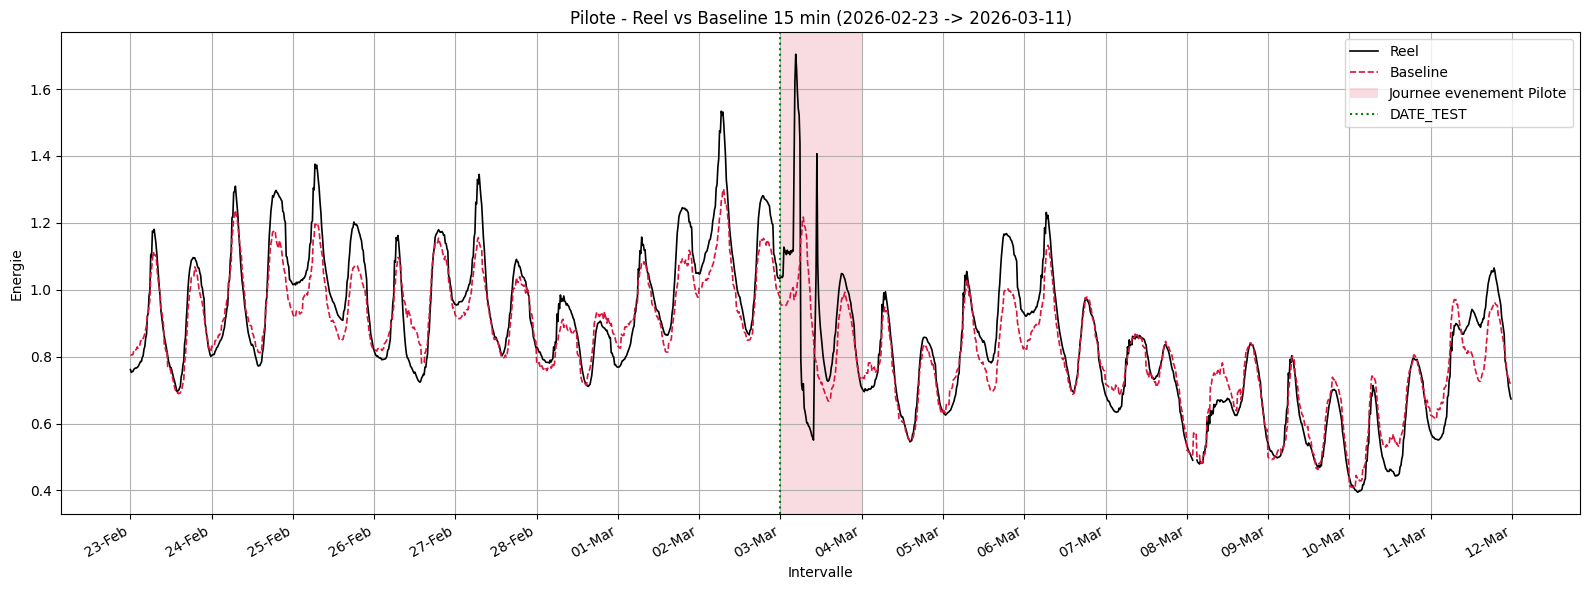

[Residentiel] event=['2026-03-03'] | maintenance=['2026-03-08', '2026-03-09']


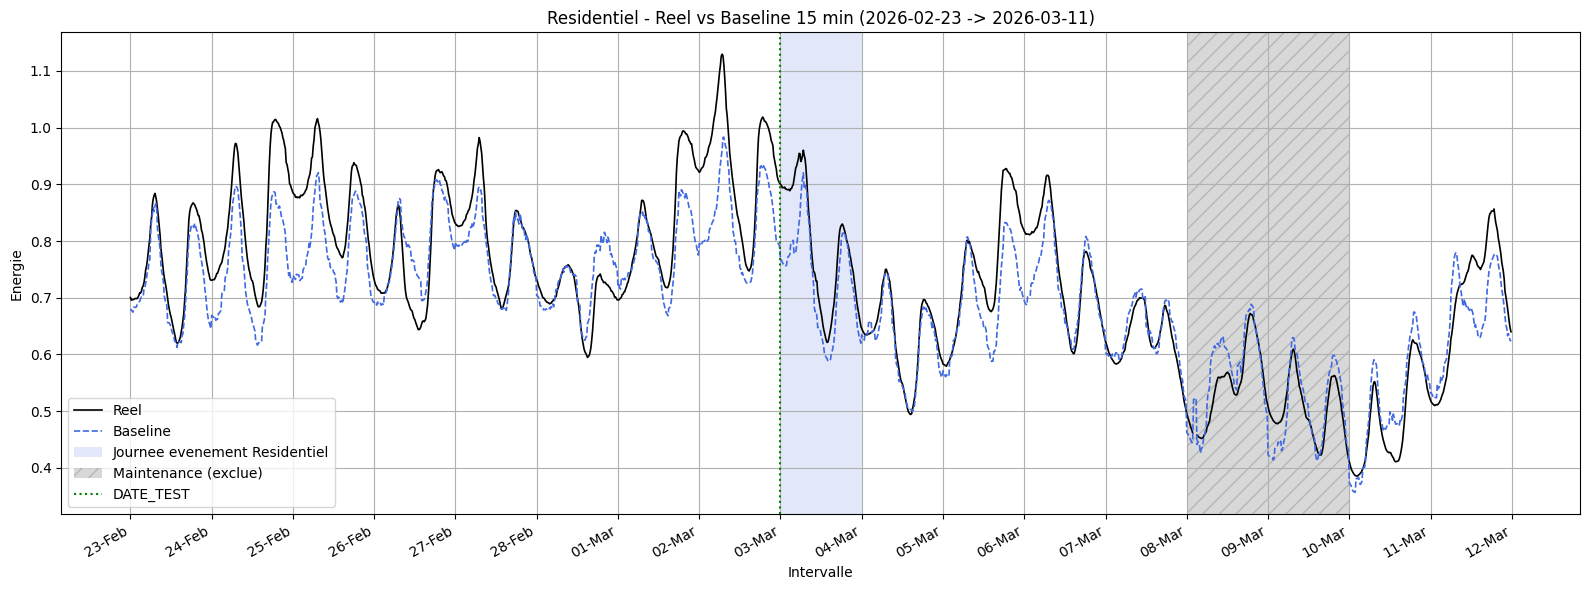

[Affaire] event=['2026-02-24', '2026-02-25', '2026-02-27', '2026-03-02', '2026-03-03', '2026-03-06'] | maintenance=[]


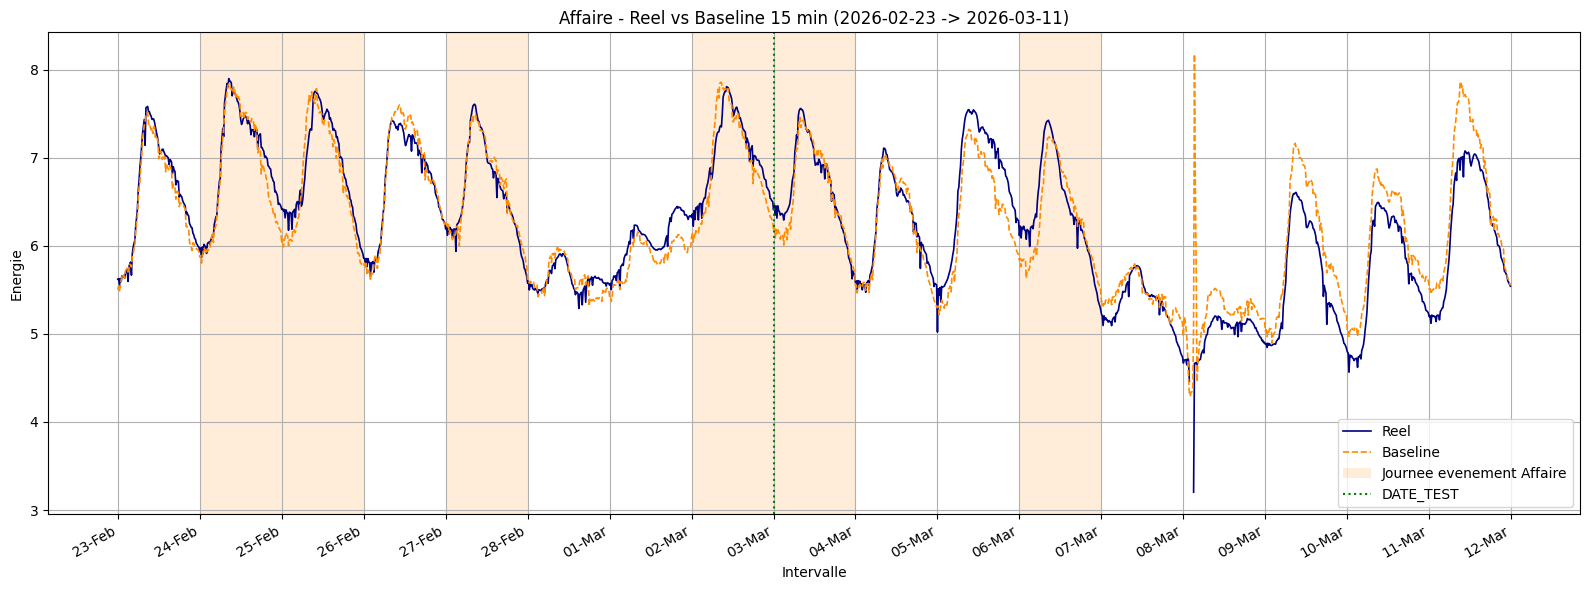

[Comportemental] event=['2026-03-03'] | maintenance=['2026-03-09']


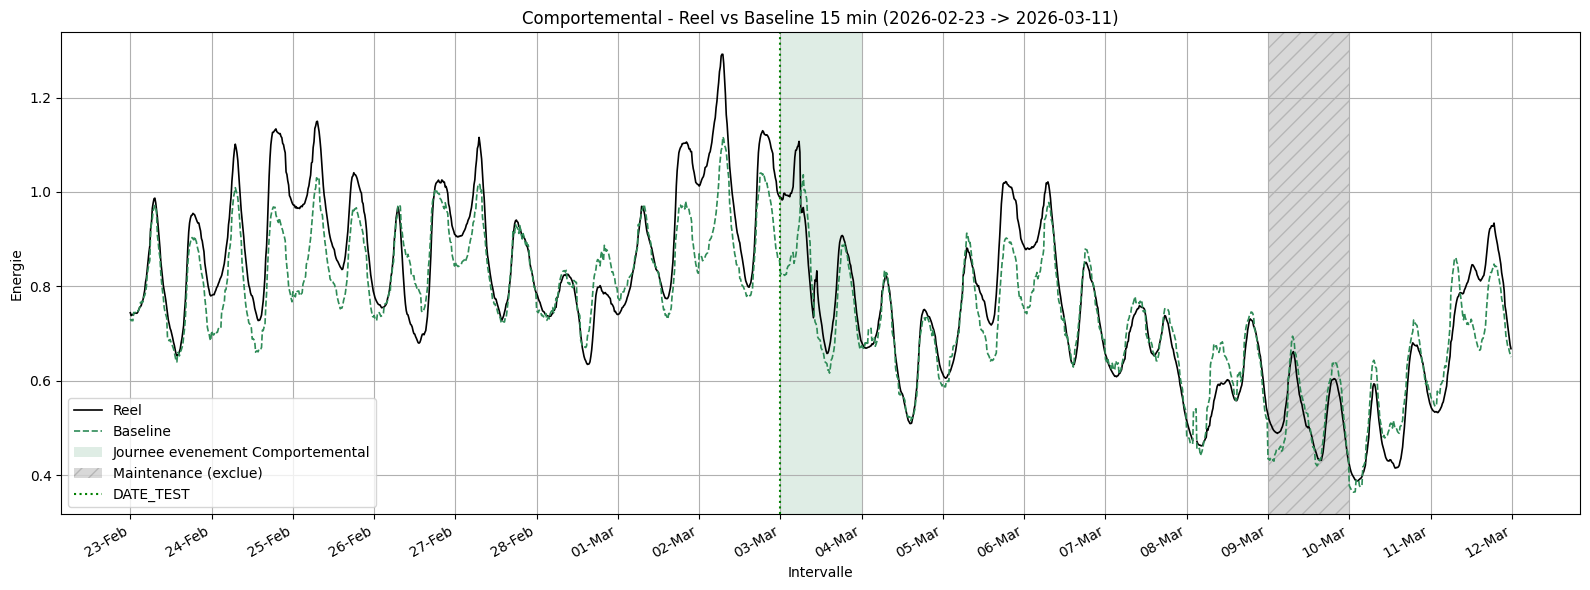

In [0]:
def _jours_par_flag(d_eval, col):
    if col not in d_eval.columns: return []
    return (d_eval.loc[d_eval[col].fillna(0).astype(int) == 1, "Intervalle"]
            .dt.normalize().drop_duplicates().sort_values().tolist())


def tracer_reel_vs_baseline_test(res, verbose=True):
    pt = res["d_eval"].copy().reset_index(drop=True)
    if len(pt) == 0:
        print(f"[{res['segment']}] Aucune donnee de test."); return
    cfg = res["cfg"]; coul_evt = cfg.get("couleur_event", "red")
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(pt["Intervalle"], pt["energie"], color=cfg["couleur_reel"], lw=1.2, label="Reel")
    ax.plot(pt["Intervalle"], pt["pred_baseline"], color=cfg["couleur_pred"], lw=1.2, ls="--", label="Baseline")

    jours_evt   = _jours_par_flag(pt, "is_event_day")
    jours_maint = _jours_par_flag(pt, "flag_maintenance")
    if verbose:
        f = lambda L: [str(x.date()) for x in L]
        print(f"[{res['segment']}] event={f(jours_evt)} | maintenance={f(jours_maint)}")

    lab = {"e": False, "m": False}
    for j in jours_evt:
        ax.axvspan(j, j+pd.Timedelta(days=1), color=coul_evt, alpha=0.15, lw=0,
                   label=None if lab["e"] else f"Journee evenement {res['segment']}"); lab["e"] = True
    for j in jours_maint:
        ax.axvspan(j, j+pd.Timedelta(days=1), facecolor="gray", alpha=0.30, hatch="//",
                   edgecolor="dimgray", lw=0, label=None if lab["m"] else "Maintenance (exclue)"); lab["m"] = True

    ax.axvline(DATE_TEST_TS, color="green", ls=":", lw=1.5, label="DATE_TEST")
    ax.set_title(f"{res['segment']} - Reel vs Baseline 15 min ({debut_test.date()} -> {fin_test.date()})")
    ax.set_xlabel("Intervalle"); ax.set_ylabel("Energie")
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    fig.autofmt_xdate(); ax.legend(loc="best"); plt.tight_layout(); plt.show()


for res in resultats_segments.values():
    tracer_reel_vs_baseline_test(res)

## 19. Importance des variables

### Explication detaillee - Cellule 19 : Importance des variables
- **`afficher_importance_baseline(res, top_n=30)`** recupere les `feature_importances_` du modele
  XGBoost du segment et affiche les `top_n` variables les plus influentes sous forme de barres.
- La boucle produit un graphique par segment, utile pour l'interpretabilite : on verifie que ce sont
  bien les profils de reference, la meteo (HDD/CDD) et le calendrier qui pilotent la baseline.

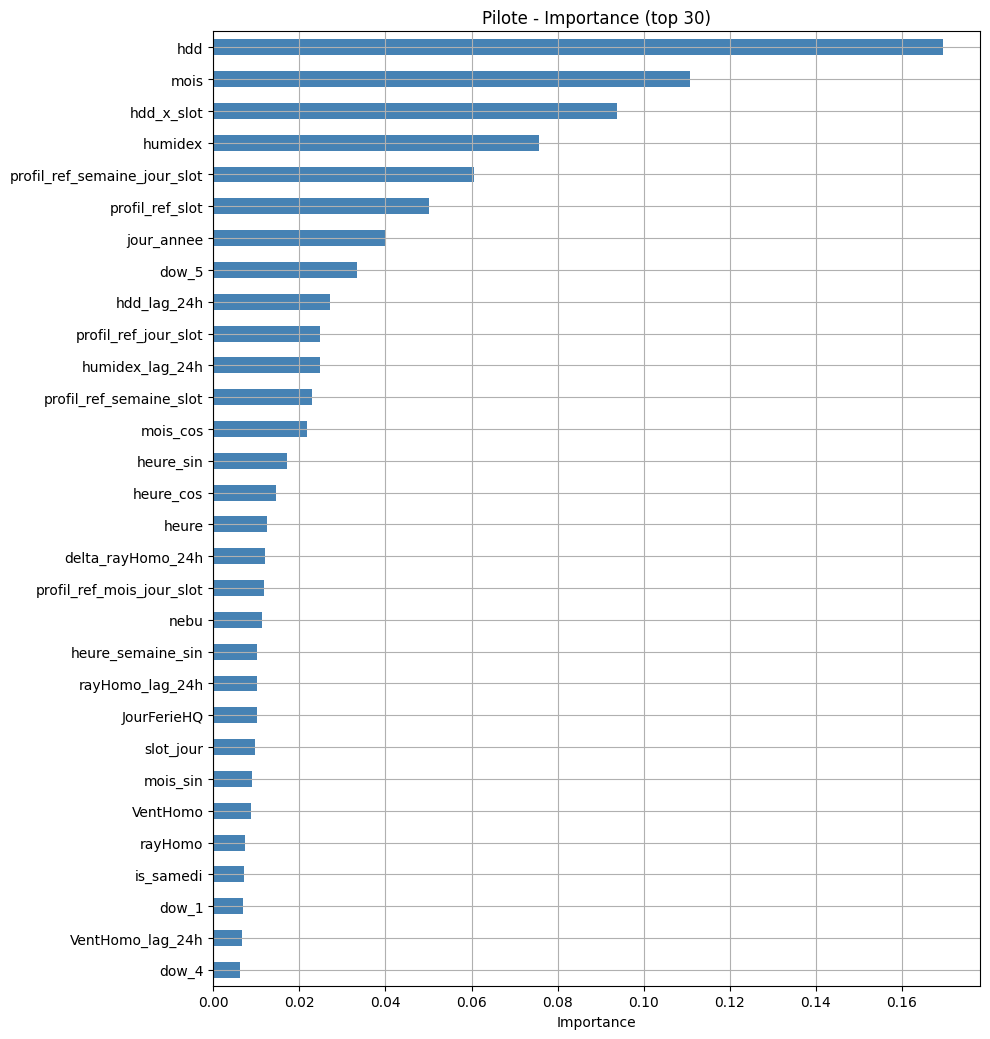

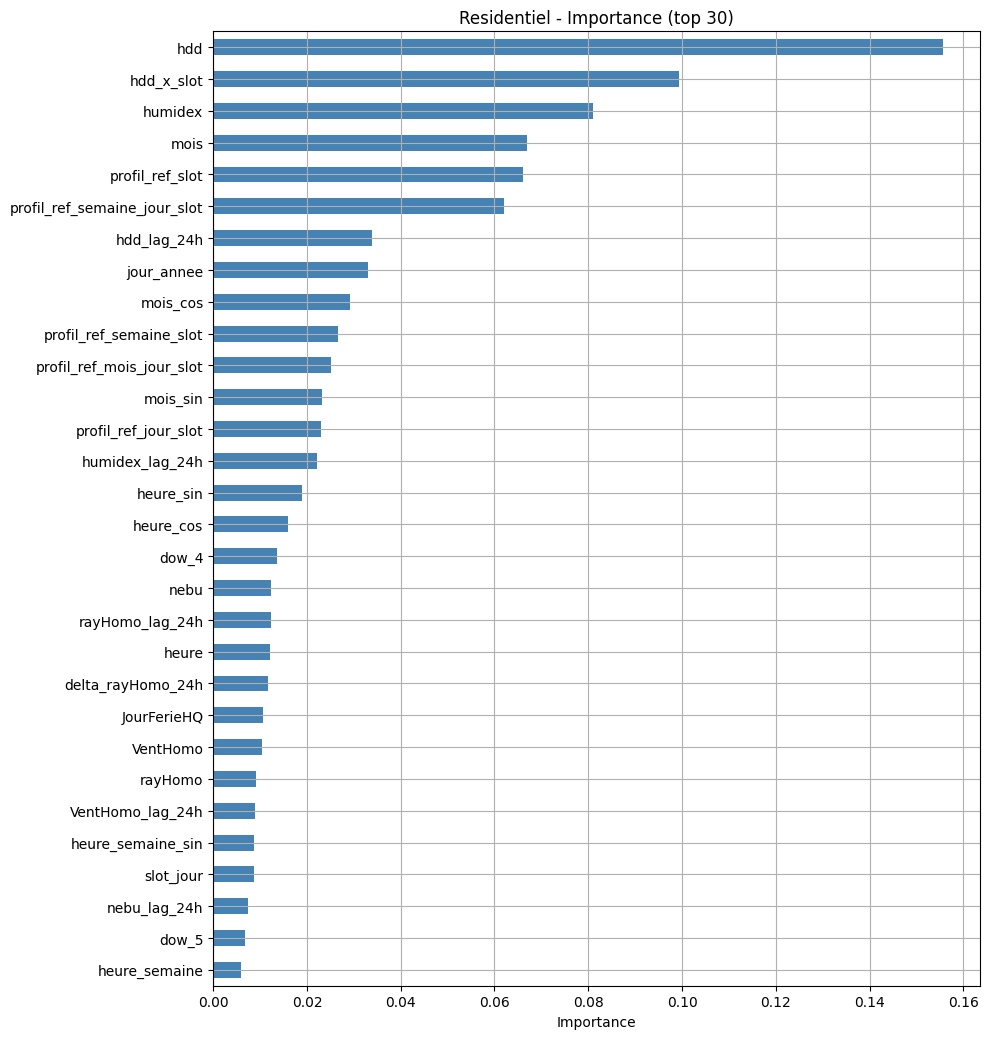

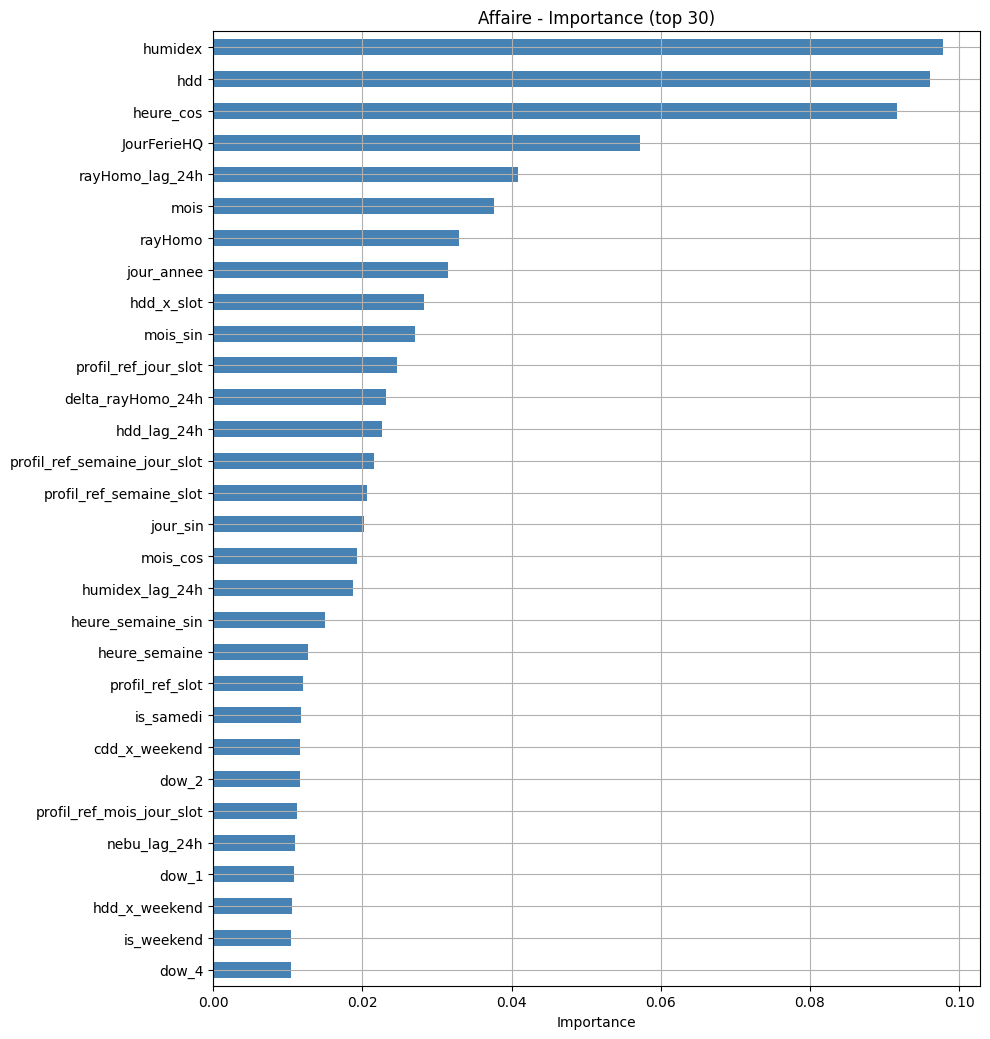

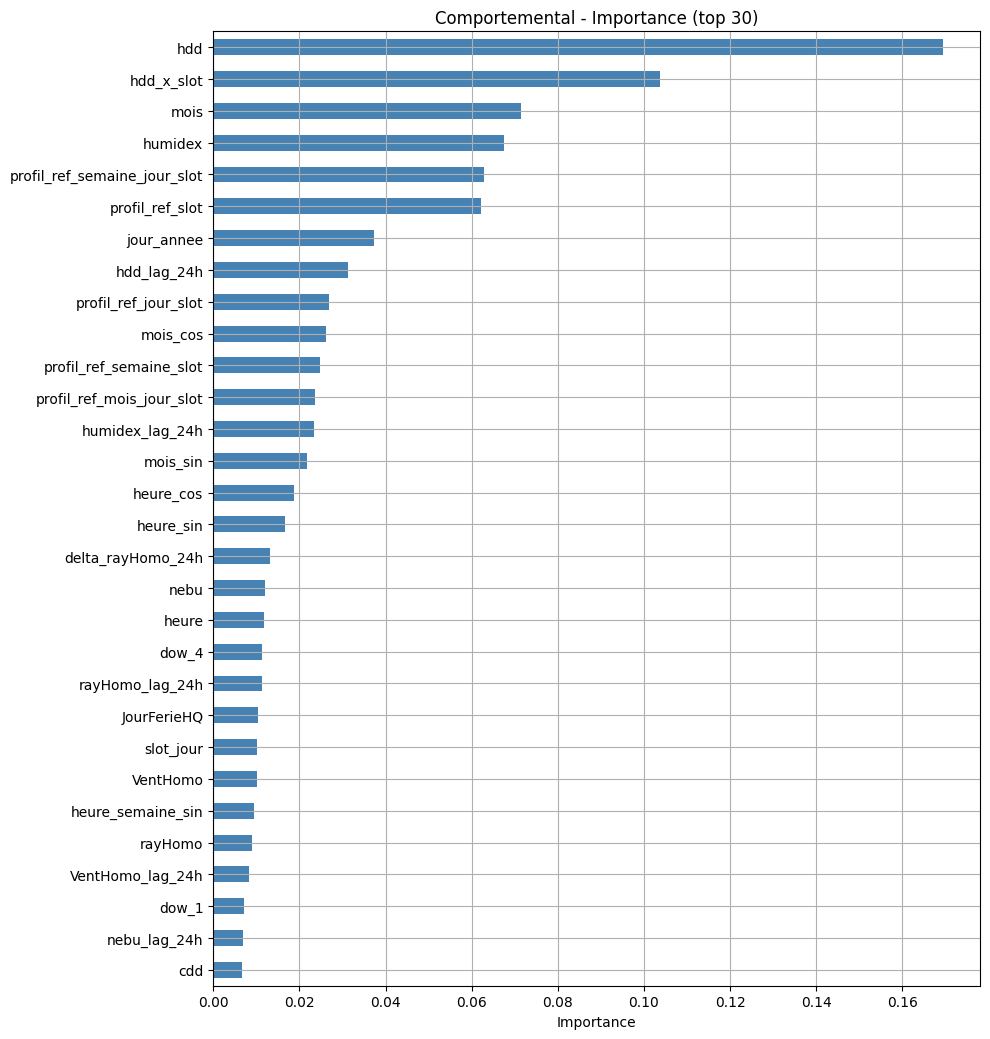

In [0]:
def afficher_importance_baseline(res, top_n=30):
    pipe = res["model_baseline"]; model = pipe.named_steps["model"]
    feats = res["features_baseline"]
    imp = getattr(model, "feature_importances_", None)
    if imp is None:
        print(f"[{res['segment']}] Pas d'importances."); return
    s = pd.Series(imp, index=feats).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35*len(s))))
    s[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{res['segment']} - Importance (top {top_n})"); ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()

for res in resultats_segments.values():
    afficher_importance_baseline(res)

## 20. Export des vues temporaires Spark

### Explication detaillee - Cellule 20 : Export des vues temporaires Spark
- On materialise `synthese`, `resume_journalier_test` et (si present) `bilan_deplacement_test` en
  **vues temporaires Spark** (`createOrReplaceTempView`).
- Cela permet de requeter ces resultats en SQL dans d'autres cellules/notebooks Databricks, ou de les
  brancher a des tableaux de bord. La cellule imprime le nom des vues creees et `Termine.`.

In [0]:
spark.createDataFrame(synthese) \
    .createOrReplaceTempView("perf_test_affaire_15min_par_segment")
spark.createDataFrame(resume_journalier_test) \
    .createOrReplaceTempView("resume_journalier_test_affaire_15min")
if len(bilan_deplacement_test):
    spark.createDataFrame(bilan_deplacement_test) \
        .createOrReplaceTempView("bilan_deplacement_charge_affaire_15min")

print("Vues temporaires creees :")
print(" - perf_test_affaire_15min_par_segment")
print(" - resume_journalier_test_affaire_15min")
print(" - bilan_deplacement_charge_affaire_15min")
print("Termine.")

Vues temporaires creees :
 - perf_test_affaire_15min_par_segment
 - resume_journalier_test_affaire_15min
 - bilan_deplacement_charge_affaire_15min
Termine.


# ============================================================
# PARTIE 2 - Comparaison Baseline XGBoost vs TFT
# ============================================================

Cellules ajoutees a la suite du notebook XGBoost 15 min (Partie 1). Elles reutilisent
`resultats_segments` (donnees + baseline XGBoost) produit ci-dessus, donc plus de `NameError`.

**Contrefactuel TFT :** entraine sur l'historique **avant** `debut_test`, puis baseline en
**prediction glissante jour par jour** (encoder = 7 j reels, decoder = 96 creneaux avec seulement
calendrier + meteo -> aucune fuite de l'evenement).

## P2.1 - Imports TFT (torch, lightning, pytorch-forecasting)

### Explication detaillee - Cellule P2.1 : Imports TFT
- Debut de la **Partie 2**. On (re)definit `_assurer` puis on installe/importe la pile deep learning :
  `torch`, `lightning`, et surtout **`pytorch-forecasting`** qui fournit `TemporalFusionTransformer`
  et `TimeSeriesDataSet`.
- On importe aussi les callbacks Lightning (early stopping, checkpoint), un `CSVLogger` inscriptible,
  le `GroupNormalizer` et la `QuantileLoss`.
- **`GPU_DISPO`** teste la disponibilite CUDA et affiche le peripherique retenu (GPU ou CPU).

In [0]:
import importlib as _il

def _assurer(pkg, pip_name=None):
    try:
        return _il.import_module(pkg)
    except ModuleNotFoundError:
        print(f"Installation de {pip_name or pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return _il.import_module(pkg)

torch = _assurer("torch")
_assurer("lightning", "lightning")
_assurer("pytorch_forecasting", "pytorch-forecasting")

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger   # logger inscriptible (corrige PermissionError)
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

GPU_DISPO = torch.cuda.is_available()
print("torch:", torch.__version__, "| CUDA:", GPU_DISPO,
      "->", (torch.cuda.get_device_name(0) if GPU_DISPO else "CPU"))

Installation de lightning ...



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
2026-08-26 17:56:29.049175: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 17:56:29.059657: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-26 17:56:29.072006: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-26 17:56:29.075726: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBL

Installation de pytorch-forecasting ...



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


torch: 2.6.0+cu124 | CUDA: True -> NVIDIA H100 NVL


## P2.1bis - Dossier de checkpoints INSCRIPTIBLE (correctif PermissionError)

Sur Databricks, le repertoire de travail est `/Workspace/Users/...` -> **lecture seule** pour
l'ecriture de fichiers par Lightning. Par defaut, `Trainer` y depose ses checkpoints, d'ou :

`PermissionError: [Errno 13] Permission denied: '/Workspace/.../checkpoints'`

On force donc **toutes les sorties Lightning** vers un disque local inscriptible. On teste
plusieurs emplacements et on retient le premier ou l'ecriture reussit.

### Explication detaillee - Cellule P2.1bis : Dossier de checkpoints inscriptible
- Sur Databricks, `/Workspace/...` est **en lecture seule** pour l'ecriture de fichiers par Lightning,
  ce qui provoque `PermissionError` lors de la sauvegarde des checkpoints.
- **`_dossier_inscriptible()`** teste plusieurs emplacements (`/local_disk0`, `/dbfs/tmp`, `/tmp`,
  dossier temporaire) et retient le **premier ou l'ecriture reussit**.
- On force `CKPT_DIR`, cree un sous-dossier de logs, et on **change le repertoire courant** vers ce
  disque inscriptible pour eviter tout `lightning_logs` relatif ecrit dans `/Workspace`.

In [0]:
import tempfile

def _dossier_inscriptible():
    candidats = ["/local_disk0/tmp/tft_ckpt",   # disque local du worker Databricks
                 "/dbfs/tmp/tft_ckpt",          # DBFS monte
                 "/tmp/tft_ckpt",
                 os.path.join(tempfile.gettempdir(), "tft_ckpt")]
    for c in candidats:
        try:
            os.makedirs(c, exist_ok=True)
            testfile = os.path.join(c, ".write_test")
            with open(testfile, "w") as f:
                f.write("ok")
            os.remove(testfile)
            return c
        except Exception:
            continue
    # dernier recours : dossier temporaire garanti
    d = tempfile.mkdtemp(prefix="tft_ckpt_")
    return d

CKPT_DIR = _dossier_inscriptible()

# --- Sous-dossiers dedies : logs Lightning + checkpoints, tous inscriptibles ---
LOG_DIR  = os.path.join(CKPT_DIR, "lightning_logs")
os.makedirs(LOG_DIR, exist_ok=True)

# Filet de securite : on force le repertoire courant vers un disque inscriptible.
# Ainsi, meme si une lib cree un "lightning_logs" RELATIF, il n'atterrit JAMAIS
# dans /Workspace (lecture seule) mais dans CKPT_DIR.
try:
    os.chdir(CKPT_DIR)
    print("Repertoire courant force vers :", os.getcwd())
except Exception as _e:
    print("Impossible de changer de repertoire courant :", _e)

print("Checkpoints TFT -> ", CKPT_DIR)
print("Logs Lightning  -> ", LOG_DIR)

Repertoire courant force vers : /local_disk0/tmp/tft_ckpt
Checkpoints TFT ->  /local_disk0/tmp/tft_ckpt
Logs Lightning  ->  /local_disk0/tmp/tft_ckpt/lightning_logs


## P2.1ter - Dossier PERSISTANT des modeles (Unity Catalog Volume)

Les checkpoints d'entrainement (CKPT_DIR) sont sur un disque local **ephemere**
(perdu au redemarrage du cluster). Pour **conserver** les modeles TFT entre deux
executions, on les copie dans un **Volume Unity Catalog** (persistant) :

    /Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique

Comportement :
- `REENTRAINER_TFT = False` (defaut) : si un modele existe deja dans le Volume pour un
  segment, il est **recharge** (pas de reentrainement).
- `REENTRAINER_TFT = True` : on **force** un nouvel entrainement et on ecrase le modele
  sauvegarde.

### Explication detaillee - Cellule P2.1ter : Dossier persistant (Volume Unity Catalog)
- `CKPT_DIR` est un disque local **ephemere** (perdu au redemarrage du cluster). Pour **conserver**
  les modeles TFT, on definit `MODELE_DIR`, un **Volume Unity Catalog** persistant.
- **`REENTRAINER_TFT`** controle le comportement : `False` recharge un modele deja sauvegarde s'il
  existe (pas de reentrainement) ; `True` force un nouvel entrainement et ecrase la sauvegarde.
- **`chemin_modele_segment(nom)`** normalise le nom du segment pour construire le chemin `.ckpt`
  du modele dans le Volume.

In [0]:
import shutil

# Dossier persistant demande (Volume Unity Catalog)
MODELE_DIR = "/Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique"

# Mettre True pour forcer un reentrainement complet et ecraser les modeles sauvegardes.
REENTRAINER_TFT = False

try:
    os.makedirs(MODELE_DIR, exist_ok=True)
    print("Dossier modeles persistant :", MODELE_DIR)
except Exception as _e:
    print("ATTENTION : impossible de creer/acceder au Volume :", _e)

def chemin_modele_segment(nom):
    """Chemin du checkpoint persistant pour un segment donne (dans le Volume)."""
    nom_propre = str(nom).strip().replace(" ", "_").lower()
    return os.path.join(MODELE_DIR, f"tft_{nom_propre}.ckpt")

Dossier modeles persistant : /Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique


## P2.2 - Hyperparametres TFT

### Explication detaillee - Cellule P2.2 : Hyperparametres TFT
- **Fenetres temporelles** : `ENC_LEN = 7 jours x 96 = 672` creneaux d'encodeur (contexte reel) et
  `DEC_LEN = 96` creneaux de decodeur (l'horizon d'un jour a predire).
- **Optimisation** : nombre d'epoques, taille de batch, learning rate, taille cachee, tetes
  d'attention, dropout, patience de l'early stopping et clipping du gradient.
- On fixe la **graine** (`SEED_TFT`) via `pl.seed_everything` pour la reproductibilite et on choisit
  l'accelerateur (`gpu`/`cpu`) selon `GPU_DISPO`.

In [0]:
ENC_JOURS = 7
DEC_JOURS = 1
ENC_LEN   = ENC_JOURS * PAS_PAR_JOUR   # 672
DEC_LEN   = DEC_JOURS * PAS_PAR_JOUR   # 96

MAX_EPOCHS      = 30
BATCH_SIZE      = 128
LEARNING_RATE   = 0.01
HIDDEN_SIZE     = 32
ATTENTION_HEADS = 4
DROPOUT         = 0.15
HIDDEN_CONT     = 16
PATIENCE        = 5
GRAD_CLIP       = 0.1
SEED_TFT        = 42

pl.seed_everything(SEED_TFT, workers=True)
ACCELERATOR = "gpu" if GPU_DISPO else "cpu"
DEVICES     = 1
print(f"Encoder={ENC_LEN} pas ({ENC_JOURS}j) | Decoder={DEC_LEN} pas | {ACCELERATOR}")

[rank: 0] Seed set to 42


Encoder=672 pas (7j) | Decoder=96 pas | gpu


## P2.3 - Preparation d'un segment pour le TFT
Grille 15 min contigue, `time_idx` entier, covariables connues sans NaN.

### Explication detaillee - Cellule P2.3 : Preparation d'un segment pour le TFT
- **`KNOWN_REALS_CANDIDATS`** liste les covariables **connues du futur** (calendrier + meteo) que le
  decodeur a le droit de voir - jamais l'evenement, pour eviter toute fuite.
- **`preparer_df_tft(d_full)`** met les donnees sur une **grille 15 min contigue** (`reindex`),
  conserve l'energie observee, **interpole** l'energie et les covariables pour supprimer les NaN,
  cree un `time_idx` entier continu et un identifiant de serie unique `s0`.
- Ce format contigu et sans NaN est une exigence stricte du `TimeSeriesDataSet` de pytorch-forecasting.

In [0]:
KNOWN_REALS_CANDIDATS = [
    "heure", "minute", "slot_jour", "jour_semaine", "mois", "jour_annee",
    "is_weekend", "is_samedi", "is_dimanche", "JourFerieHQ",
    "heure_sin", "heure_cos", "jour_sin", "jour_cos", "mois_sin", "mois_cos",
    "heure_semaine", "heure_semaine_sin", "heure_semaine_cos",
    "hdd", "cdd", "humidex", "VentHomo", "rayHomo", "nebu",
]

def preparer_df_tft(d_full):
    d = d_full.copy().sort_values("Intervalle").reset_index(drop=True)
    grille = pd.date_range(d["Intervalle"].min(), d["Intervalle"].max(), freq=FREQ)
    d = d.set_index("Intervalle").reindex(grille).rename_axis("Intervalle").reset_index()
    d["energie_obs"] = d["energie"]
    d["energie"] = d["energie"].interpolate(limit_direction="both")
    known = [c for c in KNOWN_REALS_CANDIDATS if c in d.columns]
    for c in known:
        d[c] = d[c].interpolate(limit_direction="both").ffill().bfill()
    d["time_idx"] = np.arange(len(d), dtype=np.int64)
    d["series"] = "s0"
    for c in ["event", "is_event_day", "flag_maintenance", "jour_avant_event", "jour_apres_event"]:
        if c in d.columns:
            d[c] = d[c].fillna(0).astype(int)
    d["date"] = d["Intervalle"].dt.normalize()
    return d, known

## P2.4 - Entrainement TFT (checkpoints rediriges vers CKPT_DIR)

### Explication detaillee - Cellule P2.4 : Entrainement du TFT
- **`construire_dataset_train(...)`** decoupe l'historique **avant** `debut_test`, reserve ~10 % pour
  la validation, et construit le `TimeSeriesDataSet` gabarit (encodeur/decodeur, covariables connues,
  cible `energie`, normalisation par groupe). Ce gabarit est **toujours** reconstruit, meme quand on
  recharge un modele, car il est necessaire a la prediction glissante.
- **`entrainer_tft(...)`** entraine le Temporal Fusion Transformer (ou recharge le checkpoint persistant
  selon `REENTRAINER_TFT`), avec early stopping et checkpoints rediriges vers `CKPT_DIR`, puis copie le
  modele final dans le Volume pour reutilisation ulterieure.

In [0]:
def construire_dataset_train(df, known_reals):
    """Reconstruit le TimeSeriesDataSet d'entrainement (template).
    Toujours necessaire pour la prediction glissante, meme quand on
    RECHARGE un modele deja entraine depuis le Volume."""
    cutoff = int(df.loc[df["Intervalle"] >= debut_test, "time_idx"].min())
    df_hist = df[df["time_idx"] < cutoff].copy()
    val_debut = df_hist["time_idx"].max() - int(0.10 * len(df_hist))
    dataset_train = TimeSeriesDataSet(
        df_hist[df_hist["time_idx"] <= val_debut],
        time_idx="time_idx", target="energie", group_ids=["series"],
        max_encoder_length=ENC_LEN, max_prediction_length=DEC_LEN,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=["energie"],
        target_normalizer=GroupNormalizer(groups=["series"]),
        add_relative_time_idx=True, add_target_scales=True,
        add_encoder_length=False, allow_missing_timesteps=True,
    )
    return dataset_train, df_hist, val_debut

def entrainer_tft(df, known_reals, nom):
    # --- dataset toujours reconstruit (leger, sans entrainement) ---
    dataset_train, df_hist, val_debut = construire_dataset_train(df, known_reals)

    # ============================================================
    # RELANCE : si un modele existe deja dans le Volume pour ce segment
    # et qu'on ne force pas le reentrainement -> on le RECHARGE.
    # ============================================================
    chemin_persistant = chemin_modele_segment(nom)
    if (not REENTRAINER_TFT) and os.path.exists(chemin_persistant):
        print(f"  [RECHARGE] Modele TFT existant trouve -> {chemin_persistant}")
        try:
            modele = TemporalFusionTransformer.load_from_checkpoint(chemin_persistant)
            print("  Modele recharge depuis le Volume (aucun reentrainement).")
            return modele, dataset_train
        except Exception as _e:
            print("  Echec du rechargement, on reentraine :", _e)

    # ============================================================
    # Sinon : ENTRAINEMENT complet
    # ============================================================
    print(f"  [ENTRAINEMENT] Nouveau modele TFT pour le segment '{nom}'...")
    dataset_val = TimeSeriesDataSet.from_dataset(
        dataset_train, df_hist, predict=False, stop_randomization=True,
        min_prediction_idx=val_debut + 1)

    dl_train = dataset_train.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
    dl_val   = dataset_val.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        dataset_train, learning_rate=LEARNING_RATE, hidden_size=HIDDEN_SIZE,
        attention_head_size=ATTENTION_HEADS, dropout=DROPOUT,
        hidden_continuous_size=HIDDEN_CONT, loss=QuantileLoss(),
        log_interval=-1, optimizer="adam")   # -1 : desactive le logging interne du TFT

    # ModelCheckpoint EXPLICITE vers un dossier inscriptible (corrige le PermissionError)
    ckpt = ModelCheckpoint(dirpath=CKPT_DIR, monitor="val_loss", mode="min",
                           save_top_k=1, filename="tft-{epoch:02d}-{val_loss:.4f}")

    # ============================================================
    # CORRECTIF PermissionError '/Workspace/.../lightning_logs' :
    # On fournit un LOGGER EXPLICITE ecrivant dans un dossier inscriptible
    # (CSVLogger -> CKPT_DIR/lightning_logs). Cela evite que Lightning cree
    # un 'lightning_logs' dans /Workspace (lecture seule) tout en gardant un
    # logger actif (necessaire pour EarlyStopping / LearningRateMonitor).
    # ============================================================
    logger_tft = CSVLogger(save_dir=CKPT_DIR, name="lightning_logs")

    trainer = pl.Trainer(
        default_root_dir=CKPT_DIR,          # toutes les sorties Lightning -> disque inscriptible
        max_epochs=MAX_EPOCHS, accelerator=ACCELERATOR, devices=DEVICES,
        gradient_clip_val=GRAD_CLIP,
        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, mode="min"), ckpt],
        enable_progress_bar=True, enable_model_summary=False,
        logger=logger_tft)                  # logger inscriptible au lieu de logger=False
    trainer.fit(tft, train_dataloaders=dl_train, val_dataloaders=dl_val)

    # Chargement robuste du meilleur modele (fallback sur le modele en memoire)
    best = ckpt.best_model_path
    if best and os.path.exists(best):
        modele = TemporalFusionTransformer.load_from_checkpoint(best)
    else:
        best = None
        modele = tft

    # ============================================================
    # SAUVEGARDE PERSISTANTE dans le Volume Unity Catalog
    # (le checkpoint local est ephemere -> on le copie dans le Volume)
    # ============================================================
    try:
        if best and os.path.exists(best):
            shutil.copyfile(best, chemin_persistant)          # copie du meilleur checkpoint
        else:
            trainer.save_checkpoint(chemin_persistant)         # fallback : sauvegarde directe
        print(f"  [SAUVEGARDE] Modele TFT sauvegarde -> {chemin_persistant}")
    except Exception as _e:
        print("  ATTENTION : echec de la sauvegarde dans le Volume :", _e)

    return modele, dataset_train

## P2.5 - Baseline TFT glissante jour par jour

### Explication detaillee - Cellule P2.5 : Baseline TFT glissante jour par jour
- **`baseline_tft_glissante(...)`** produit la baseline contrefactuelle en avancant **jour par jour**
  sur la fenetre de test.
- Pour chaque jour D : on prend 7 jours reels comme **encodeur** et on demande au modele de predire
  les **96 creneaux** de D a partir des seules covariables calendrier + meteo (**decodeur**), sans
  jamais lui montrer l'evenement -> aucune fuite.
- Les predictions journalieres sont concatenees en une serie continue `pred_tft` alignee sur `Intervalle`.

In [0]:
def baseline_tft_glissante(df, modele, dataset_train):
    jours_test = pd.date_range(debut_test.normalize(), fin_test.normalize(), freq="D")
    morceaux = []
    for D in jours_test:
        fin_D = D + pd.Timedelta(days=1) - pd.Timedelta(minutes=15)
        sl = df[(df["Intervalle"] >= D - pd.Timedelta(days=ENC_JOURS)) &
                (df["Intervalle"] <= fin_D)].copy()
        if len(sl) < ENC_LEN + DEC_LEN:
            continue
        sl = sl.iloc[-(ENC_LEN + DEC_LEN):].copy()
        ds = TimeSeriesDataSet.from_dataset(dataset_train, sl, predict=True, stop_randomization=True)
        dl = ds.to_dataloader(train=False, batch_size=1, num_workers=0)
        yhat = np.asarray(modele.predict(dl, mode="prediction")).reshape(-1)[:DEC_LEN]
        jour = sl.iloc[-DEC_LEN:][["Intervalle", "date"]].copy()
        jour["pred_tft"] = yhat
        morceaux.append(jour)
    if not morceaux:
        return pd.DataFrame(columns=["Intervalle", "date", "pred_tft"])
    return pd.concat(morceaux, ignore_index=True)

## P2.6 - Execution TFT sur les 4 segments

### Explication detaillee - Cellule P2.6 : Execution du TFT sur les 4 segments
- **`metriques_tft(...)`** est l'equivalent TFT du calcul de metriques (RMSE, MAE, R2, BIAS, N).
- La boucle applique a chaque segment : preparation TFT, entrainement/rechargement, baseline glissante,
  puis **fusion** de `pred_tft` avec le tableau d'evaluation deja produit par la baseline XGBoost.
- Le resultat est stocke dans `resultats_tft`, avec un decompte des points effectivement predits par le TFT.

In [0]:
def metriques_tft(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    m = np.isfinite(y_true) & np.isfinite(y_pred); y_true, y_pred = y_true[m], y_pred[m]
    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "BIAS": np.nan, "N": 0}
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "R2":   float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
            "BIAS": float(np.mean(y_pred - y_true)), "N": int(len(y_true))}

resultats_tft = {}
for nom, res in resultats_segments.items():
    print(f"\n========  TFT - SEGMENT : {nom}  ========")
    df_tft, known = preparer_df_tft(res["d_full"])
    modele, dataset_train = entrainer_tft(df_tft, known, nom)
    base_tft = baseline_tft_glissante(df_tft, modele, dataset_train)
    d_eval = res["d_eval"][["Intervalle", "energie", "pred_baseline",
                            "event", "is_event_day"]].copy()
    d_eval = d_eval.merge(base_tft[["Intervalle", "pred_tft"]], on="Intervalle", how="left")
    resultats_tft[nom] = {"segment": nom, "d_eval": d_eval, "modele": modele, "cfg": res["cfg"]}
    print(f"  Points avec baseline TFT : {d_eval['pred_tft'].notna().sum()} / {len(d_eval)}")
print("\nTFT termine.")


========  TFT - SEGMENT : Pilote  ========
  [RECHARGE] Modele TFT existant trouve -> /Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique/tft_pilote.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Modele recharge depuis le Volume (aucun reentrainement).


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Points avec baseline TFT : 1632 / 1632

========  TFT - SEGMENT : Residentiel  ========
  [RECHARGE] Modele TFT existant trouve -> /Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique/tft_residentiel.ckpt


...

  Points avec baseline TFT : 1632 / 1632

========  TFT - SEGMENT : Comportemental  ========
  [RECHARGE] Modele TFT existant trouve -> /Volumes/ct_prd_conf/db_xkj_zx_expdonnees_intmarche_conception/vehiculeelectrique/tft_comportemental.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Modele recharge depuis le Volume (aucun reentrainement).


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Points avec baseline TFT : 1632 / 1632

TFT termine.


## P2.7 - Synthese comparative XGBoost vs TFT
Comparaison sur les **jours propres** (hors evenement), la ou la baseline doit coller au reel.

### Explication detaillee - Cellule P2.7 : Synthese comparative XGBoost vs TFT
- On compare les deux baselines **uniquement sur les jours propres** (hors evenement), la ou la
  baseline doit coller au reel - c'est le bon terrain d'evaluation d'un contrefactuel.
- Pour chaque segment et chaque modele (XGBoost via `pred_baseline`, TFT via `pred_tft`) on calcule les
  metriques, puis on determine le **gagnant** par R2 et le **gain de R2** du TFT sur XGBoost.
- Les tableaux `comparaison` et `resume` sont imprimes et, si possible, affiches en DataFrames Spark.

In [0]:
lignes = []
for nom, r in resultats_tft.items():
    propres = r["d_eval"][r["d_eval"]["is_event_day"].fillna(0).astype(int) == 0]
    for mn, col in [("XGBoost", "pred_baseline"), ("TFT", "pred_tft")]:
        sub = propres.dropna(subset=[col])
        lignes.append({"segment": nom, "modele": mn, **metriques_tft(sub["energie"], sub[col])})
comparaison = pd.DataFrame(lignes)
print(comparaison.round(4).to_string(index=False))

resume = []
for nom in resultats_tft:
    xgb_r2 = comparaison.query("segment==@nom and modele=='XGBoost'")["R2"].values[0]
    tft_r2 = comparaison.query("segment==@nom and modele=='TFT'")["R2"].values[0]
    resume.append({"segment": nom, "R2_XGBoost": xgb_r2, "R2_TFT": tft_r2,
                   "gagnant": "TFT" if tft_r2 > xgb_r2 else "XGBoost",
                   "gain_R2": round(tft_r2 - xgb_r2, 4)})
resume = pd.DataFrame(resume)
print("\n", resume.to_string(index=False))
try:
    display(spark.createDataFrame(comparaison))
    display(spark.createDataFrame(resume))
except Exception:
    pass

       segment  modele   RMSE    MAE     R2    BIAS    N
        Pilote XGBoost 0.0682 0.0528 0.8976 -0.0196 1532
        Pilote     TFT 0.0402 0.0302 0.9644 -0.0080 1532
   Residentiel XGBoost 0.0614 0.0462 0.8375 -0.0256 1532
   Residentiel     TFT 0.0183 0.0140 0.9856 -0.0026 1532
       Affaire XGBoost 0.2944 0.2152 0.8470  0.0740 1052
       Affaire     TFT 0.1423 0.0935 0.9643  0.0535 1052
Comportemental XGBoost 0.0723 0.0534 0.8406 -0.0278 1532
Comportemental     TFT 0.0327 0.0250 0.9673  0.0171 1532

        segment  R2_XGBoost   R2_TFT gagnant  gain_R2
        Pilote    0.897595 0.964446     TFT   0.0669
   Residentiel    0.837453 0.985631     TFT   0.1482
       Affaire    0.847025 0.964273     TFT   0.1172
Comportemental    0.840575 0.967342     TFT   0.1268


segment,modele,RMSE,MAE,R2,BIAS,N
Pilote,XGBoost,0.06820328667540058,0.052778680813026724,0.8975954214335211,-0.019619820371066077,1532
Pilote,TFT,0.04018759395864629,0.03024216609259487,0.9644456470944702,-0.007999527973584353,1532
Residentiel,XGBoost,0.06141389546526853,0.04622358069564545,0.8374533385018544,-0.025646051531838698,1532
Residentiel,TFT,0.0182593743615995,0.014010291637783254,0.9856313307207972,-0.0025958469439027925,1532
Affaire,XGBoost,0.2944227887311047,0.21519045237474105,0.8470246269133679,0.07397944950444045,1052
Affaire,TFT,0.1422853756901175,0.09350820732089571,0.964272781422448,0.05345933043679183,1052
Comportemental,XGBoost,0.07232035017382445,0.05339057757778039,0.8405750641865873,-0.02780708197978141,1532
Comportemental,TFT,0.032732231548747534,0.025041693604917772,0.9673422365021456,0.01713136086381627,1532


segment,R2_XGBoost,R2_TFT,gagnant,gain_R2
Pilote,0.8975954214335211,0.9644456470944702,TFT,0.0669
Residentiel,0.8374533385018544,0.9856313307207972,TFT,0.1482
Affaire,0.8470246269133679,0.964272781422448,TFT,0.1172
Comportemental,0.8405750641865873,0.9673422365021456,TFT,0.1268


## P2.8 - Graphiques Reel vs Baseline XGBoost vs TFT
On **ne colore que les jours d'evenement** (creneaux `event == 1`), en 15 min sans agregation.

### Explication detaillee - Cellule P2.8 : Graphiques Reel vs XGBoost vs TFT
- **`_bandes_evenement(...)`** colore uniquement les **creneaux d'evenement** (bandes verticales), en
  regroupant les creneaux 15 min contigus en plages continues.
- **`tracer_comparaison(r)`** superpose sur un meme graphique la courbe **reelle**, la **baseline
  XGBoost** et la **baseline TFT**, permettant une comparaison visuelle directe des deux contrefactuels.
- La boucle produit un graphique par segment.

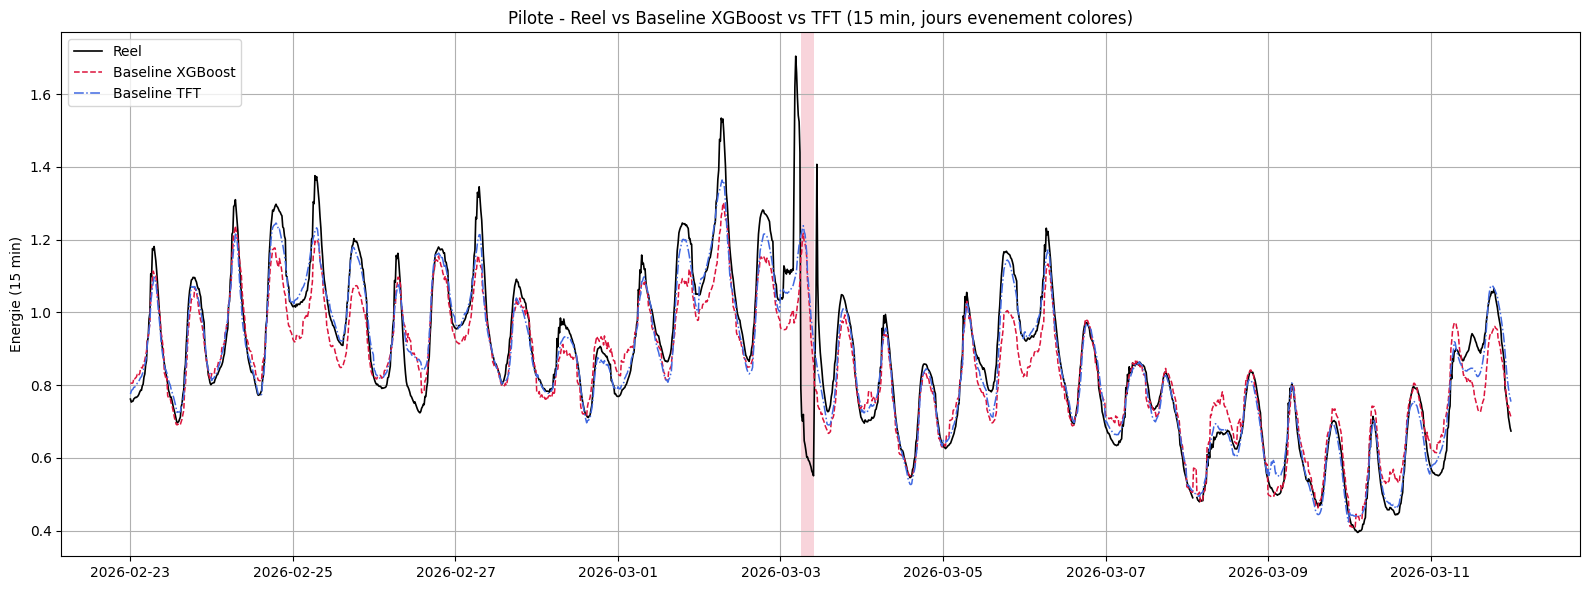

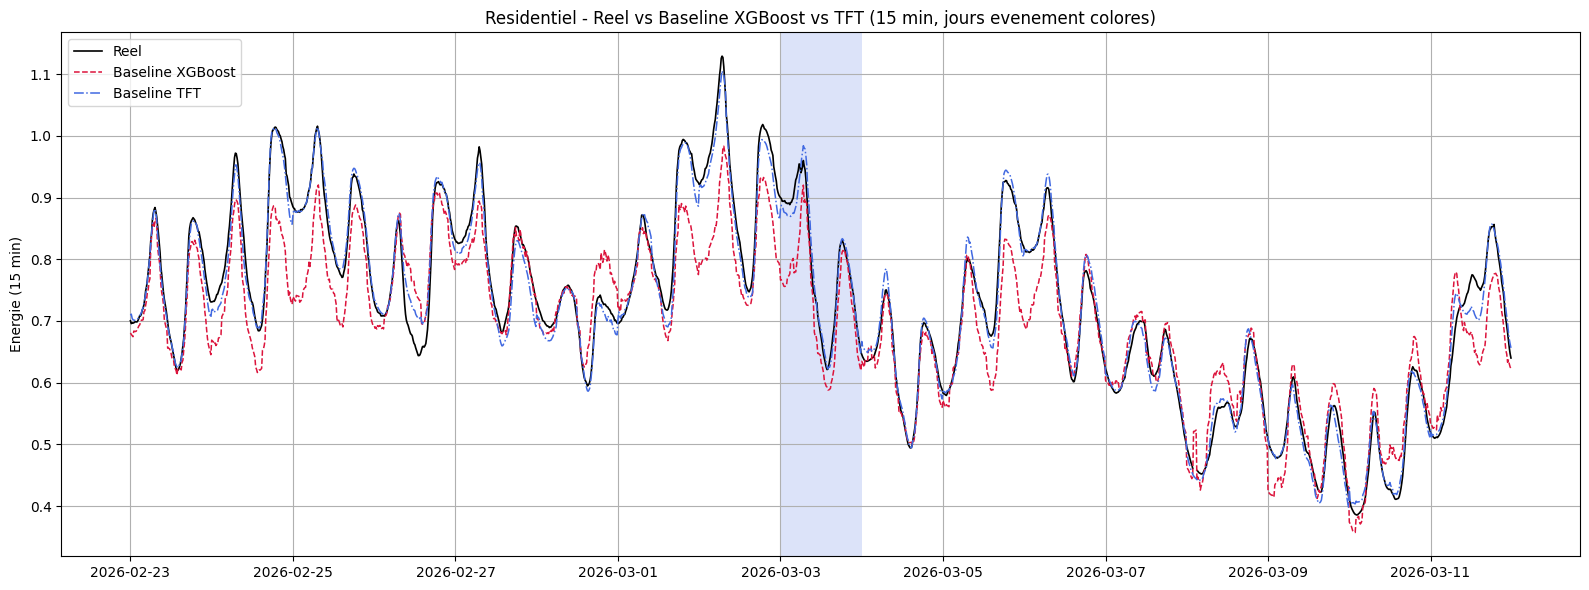

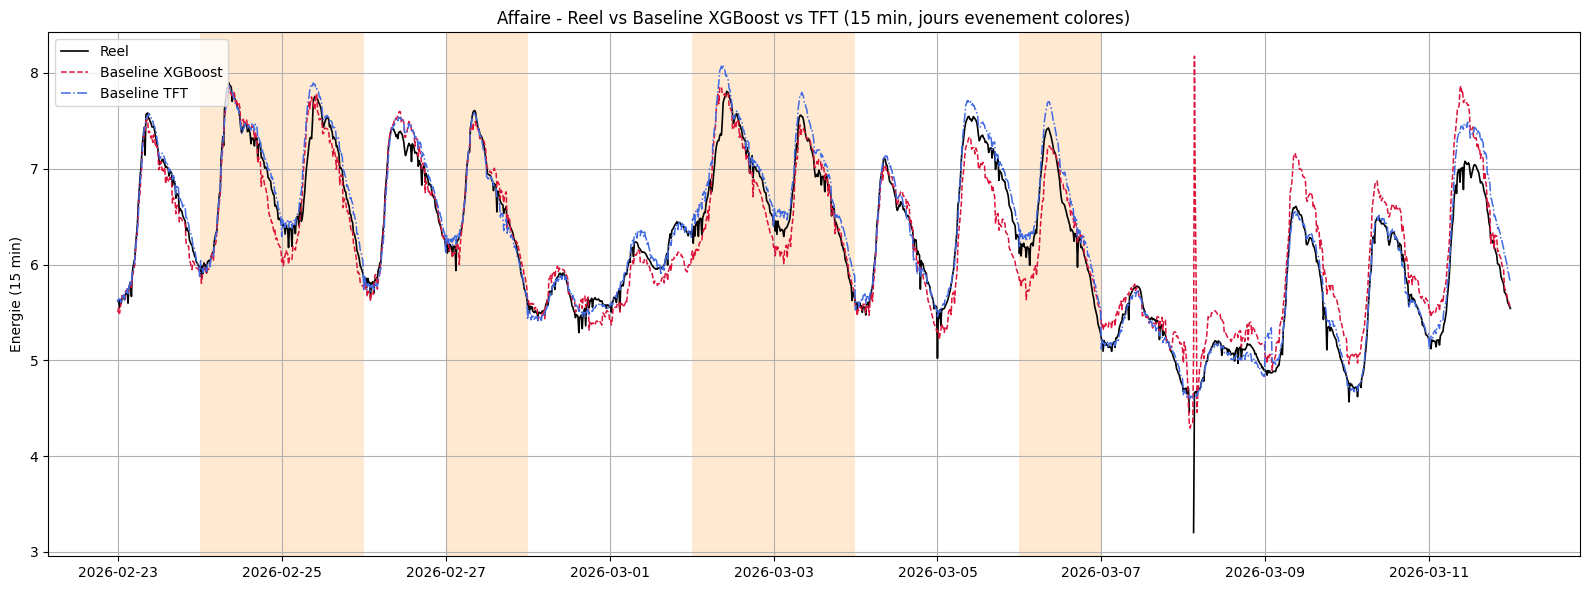

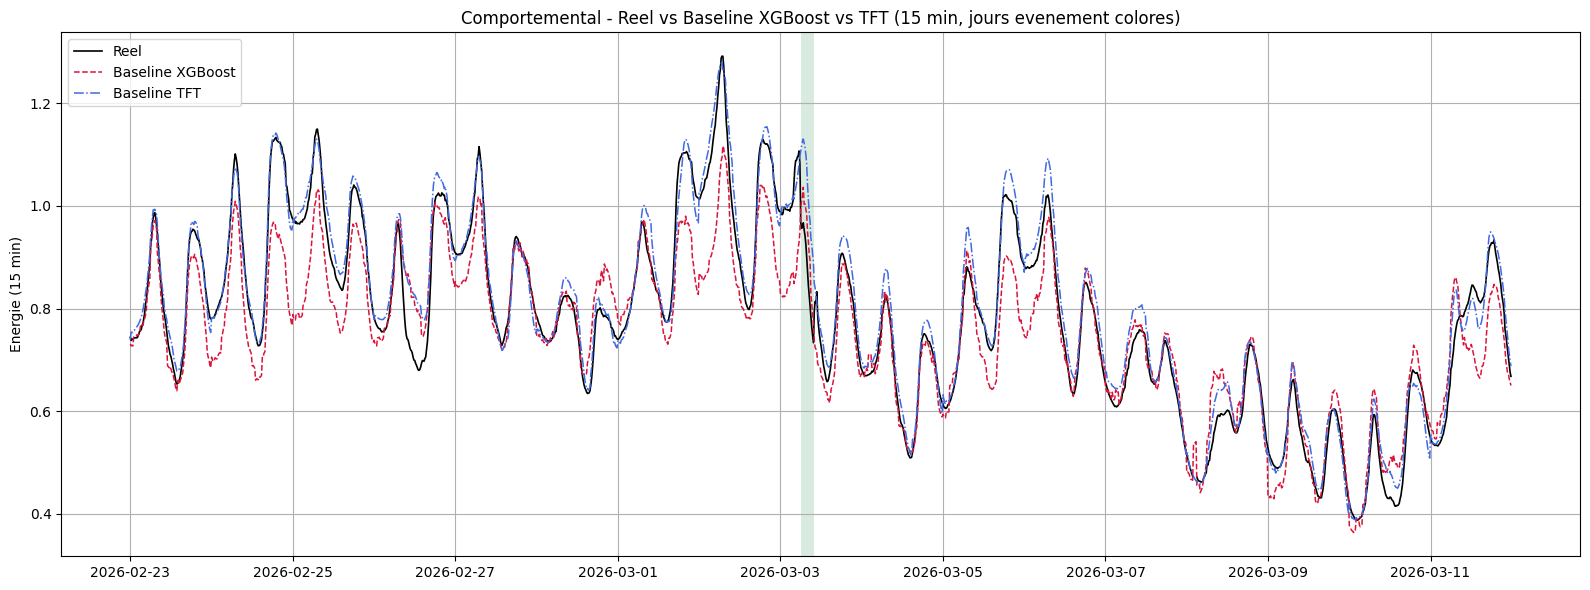

In [0]:
def _bandes_evenement(ax, d_eval, couleur):
    ev = d_eval[d_eval["event"].fillna(0).astype(int) == 1].sort_values("Intervalle")
    if ev.empty:
        return
    pas = pd.Timedelta(minutes=15); t = ev["Intervalle"].tolist()
    debut = t[0]; prec = t[0]
    for cur in t[1:]:
        if cur - prec > pas:
            ax.axvspan(debut, prec + pas, color=couleur, alpha=0.18, lw=0); debut = cur
        prec = cur
    ax.axvspan(debut, prec + pas, color=couleur, alpha=0.18, lw=0)

def tracer_comparaison(r):
    d = r["d_eval"].sort_values("Intervalle"); cfg = r["cfg"]
    fig, ax = plt.subplots(figsize=(16, 6))
    _bandes_evenement(ax, d, cfg.get("couleur_event", "red"))
    ax.plot(d["Intervalle"], d["energie"],       color="black",     lw=1.2, label="Reel")
    ax.plot(d["Intervalle"], d["pred_baseline"], color="crimson",   lw=1.1, ls="--", label="Baseline XGBoost")
    ax.plot(d["Intervalle"], d["pred_tft"],      color="royalblue", lw=1.1, ls="-.", label="Baseline TFT")
    ax.set_title(f"{r['segment']} - Reel vs Baseline XGBoost vs TFT (15 min, jours evenement colores)")
    ax.set_ylabel("Energie (15 min)"); ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

for r in resultats_tft.values():
    tracer_comparaison(r)

## P2.9 - Export des vues Spark

### Explication detaillee - Cellule P2.9 : Export des vues Spark (Partie 2)
- On publie en **vues temporaires Spark** la comparaison (`comparaison_xgb_tft_15min`), le resume des
  gagnants (`resume_gagnant_xgb_tft_15min`) et le detail creneau par creneau des deux baselines
  (`detail_baselines_xgb_tft_15min`).
- Ces vues rendent les resultats de la comparaison exploitables en SQL/tableaux de bord. Une gestion
  d'exception affiche un message si Spark n'est pas disponible. La cellule imprime `Termine.`.

In [0]:
try:
    spark.createDataFrame(comparaison).createOrReplaceTempView("comparaison_xgb_tft_15min")
    spark.createDataFrame(resume).createOrReplaceTempView("resume_gagnant_xgb_tft_15min")
    detail = pd.concat([
        r["d_eval"].assign(segment=nom)[["segment", "Intervalle", "energie",
                                         "pred_baseline", "pred_tft", "event", "is_event_day"]]
        for nom, r in resultats_tft.items()], ignore_index=True)
    spark.createDataFrame(detail).createOrReplaceTempView("detail_baselines_xgb_tft_15min")
    print("Vues creees : comparaison_xgb_tft_15min, resume_gagnant_xgb_tft_15min, detail_baselines_xgb_tft_15min")
except Exception as e:
    print("Spark indisponible :", e)
print("Termine.")

Vues creees : comparaison_xgb_tft_15min, resume_gagnant_xgb_tft_15min, detail_baselines_xgb_tft_15min
Termine.
